[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap02/cap02.EPs_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

## 💻 **Parte Prática com Exercícios de Programação**

---

### 🎯 Objetivo deste Caderno {.unnumbered}

O caderno permite desenvolver, validar, organizar e testar soluções de  **Exercícios de Programação (EPs)** em ambientes interativos, como o Colab, com os mesmos casos de teste do Moodle, copiando para lá apenas na hora de registrar a nota oficial.

#### *Download* {.unnumbered}

Baixe `morph.py` e `testsuite.py` executando a célula abaixo:

In [ ]:
import os, sys, importlib, inspect, urllib.request

# URLs do repositório
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py", "testsuite.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph, testsuite
importlib.reload(morph); importlib.reload(testsuite)
from morph import mm
from testsuite import TestSuite

print(f"✅ Ambiente pronto. Morph: {morph.__version__} | TestSuite: {testsuite.__version__}")

✅ Ambiente pronto. Morph: 1.1.0 | TestSuite: 1.1.0


### EP02_01 ☀️ Ajuste de Brilho e Contraste

Nesta atividade, o objetivo é implementar um operador de ponto para **transformação linear de intensidade**, aplicando o ajuste dinâmico de brilho e contraste em uma imagem digital.

#### 📋 Diretrizes de Implementação

O algoritmo deve seguir o fluxo de execução abaixo:

1. **Dimensões:** Ler os inteiros $L$ (linhas) e $C$ (colunas) da matriz.
2. **Parâmetros:** Ler o valor real $\alpha$ (fator de contraste) e o inteiro $\beta$ (fator de brilho).
3. **Dados:** Ler os valores inteiros da matriz original.
4. **Mapeamento:** Para cada pixel $p$, calcular o novo valor $p'$ pela equação:

$$p' = \text{clip}(\text{round}(\alpha \cdot p + \beta))$$

5. **Saída:** Exibir a matriz resultante com as dimensões $L \times C$.

---

#### 📌 Restrições Computacionais

* **Arredondamento (*Round*):** Aplica-se o arredondamento matemático para o inteiro mais próximo antes da conversão de tipo.
* **Saturação (*Clipping*):** Os valores devem ser confinados ao intervalo $[0, 255]$ para preservar o padrão de 8 bits:

$$\text{clip}(x) = \max(0, \min(255, x))$$

* **Simulação:** O efeito dos parâmetros $\alpha$ e $\beta$ na correção histogramática pode ser observado na @fig-02-bril-cont.

---

#### 🧠 Fundamentação Teórica

As alterações modificam o histograma da imagem para ajustar o perfil de iluminação e a distinção tonal.

| Parâmetro | Função | Impacto Visual |
| --- | --- | --- |
| **$\alpha$ (*Alpha*)** | Escalar | Modula o **Contraste**. Se $\alpha > 1$, expande o histograma; se $0 \le \alpha < 1$, comprime. |
| **$\beta$ (*Beta*)** | Aditiva | Modula o **Brilho**. Se positivo, translada o histograma para a direita; se negativo, para a esquerda. |
| **$\text{clip}$** | Limitador | Restringe a faixa dinâmica, impedindo erros de *underflow* e *overflow*. |

---

#### 📦 Especificação de Entrada e Saída (VPL)

**Entrada:**

* Linha 1: Inteiro $L$.
* Linha 2: Inteiro $C$.
* Linha 3: Valores de `alpha` ($\alpha$) e `beta` ($\beta$).
* Linhas seguintes: Elementos numéricos da matriz original.

**Saída:**

* Matriz transformada estruturada em $L$ linhas e $C$ colunas.

#### 📌 Exemplos

A tabela a seguir apresenta um exemplo prático do comportamento esperado do algoritmo, destacando a atuação dos operadores de arredondamento e saturação.

| Entrada | Saída | Observação |
| --- | --- | --- |
| 1<br>4<br>1.5 -30<br>0 100 180 255 | 0 120 240 255 | Note o efeito de saturação no último pixel |


---

#### Executando os Testes {.unnumbered}

Para rodar os testes, execute `TestSuite("EP02_01.extensão").run()` numa nova célula, trocando a extensão pela da linguagem usada (`.py`, `.java`, `.c`, `.cpp`, `.js` ou `.r`). O sistema baixa os casos de teste do GitHub, executa o programa e calcula a nota automaticamente.

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-bril-cont
#| fig-cap: "Simulador: Ajuste de Brilho e Contraste"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-adj-08" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Brilho e Contraste</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">☀️ p' = αp + β</span>
    </div>

    <div style="padding: 20px; background: white;">
        <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px; display: grid; grid-template-columns: 1fr 1fr; gap: 30px;">
            <div>
                <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                    <label style="font-size: 12px; font-weight: bold; color: #f39c12;">α (Contraste)</label>
                    <span id="vl-alpha-08" style="font-family: monospace; font-weight: bold; color: #f39c12;">1.0</span>
                </div>
                <input id="sl-alpha-08" style="width: 100%; accent-color: #f39c12;" max="3" min="0" step="0.1" type="range" value="1">
            </div>
            <div>
                <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                    <label style="font-size: 12px; font-weight: bold; color: #3498db;">β (Brilho)</label>
                    <span id="vl-beta-08" style="font-family: monospace; font-weight: bold; color: #3498db;">0</span>
                </div>
                <input id="sl-beta-08" style="width: 100%; accent-color: #3498db;" max="100" min="-100" step="1" type="range" value="0">
            </div>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
                <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Entrada Original</p>
                <div id="grid-orig-08" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
                <button id="btn-new-08" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Imagem</button>
            </div>
            
            <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
                <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Resultado (p')</p>
                <div id="grid-new-08" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
                <button id="btn-reset-08" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar</button>
            </div>
        </div>

        <div id="debug-08" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
            Fórmula: clip(1.0 * p + 0)
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const slAlpha = document.getElementById('sl-alpha-08');
    const slBeta = document.getElementById('sl-beta-08');
    const vlAlpha = document.getElementById('vl-alpha-08');
    const vlBeta = document.getElementById('vl-beta-08');
    const gridOrig = document.getElementById('grid-orig-08');
    const gridNew = document.getElementById('grid-new-08');
    const debug = document.getElementById('debug-08');

    if (!slAlpha || !gridOrig) return;

    let pixels = [];
    const count = 16;

    function generate() {
        pixels = Array.from({length: count}, () => Math.floor(Math.random() * 256));
    }

    function render() {
        const a = parseFloat(slAlpha.value);
        const b = parseInt(slBeta.value);

        vlAlpha.innerText = a.toFixed(1);
        vlBeta.innerText = b;
        debug.innerHTML = `Fórmula aplicada: <b>clip( round(${a.toFixed(1)} * p + (${b})) )</b>`;

        gridOrig.innerHTML = '';
        gridNew.innerHTML = '';

        pixels.forEach(p => {
            // Original
            const cellO = document.createElement('div');
            cellO.style.cssText = `width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;`;
            cellO.style.background = `rgb(${p},${p},${p})`;
            cellO.style.color = p > 128 ? 'black' : 'white';
            cellO.innerText = p;
            gridOrig.appendChild(cellO);

            // Transformado
            let res = Math.round(a * p + b);
            res = Math.max(0, Math.min(255, res));

            const cellN = document.createElement('div');
            cellN.style.cssText = `width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #ddd; transition: 0.2s;`;
            cellN.style.background = `rgb(${res},${res},${res})`;
            cellN.style.color = res > 128 ? 'black' : 'white';
            cellN.innerText = res;
            gridNew.appendChild(cellN);
        });
    }

    slAlpha.oninput = render;
    slBeta.oninput = render;
    document.getElementById('btn-new-08').onclick = () => { generate(); render(); };
    document.getElementById('btn-reset-08').onclick = () => { slAlpha.value = 1; slBeta.value = 0; render(); };

    generate();
    render();
}, 100);
</script>
     
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Ajuste de Brilho e Contraste ](imagens/fig-02-bril-cont.png){#fig-02-bril-cont}
:::

In [ ]:
%%writefile EP02_01.py
# sua solução

Overwriting EP02_01.py


In [ ]:
TestSuite("EP02_01.py").run()

---

### EP02_02 🔬 Subamostragem Espacial

Nesta atividade, você deve implementar a redução da resolução espacial de uma imagem através do processo de subamostragem.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz original.
* Leia um valor inteiro **$f$** ($f \ge 1$), que representa o fator de amostragem.
* Leia os valores inteiros da matriz original.
* A nova imagem deve ser construída selecionando o pixel da posição $(f \cdot i, f \cdot j)$ da imagem original.
* Imprima a matriz resultante com as novas dimensões.
* Ver na @fig-02-sim-suba uma simulação deste EP.

📌 **Importante**:

* **Dimensões Finais:** A imagem amostrada terá dimensões $\lceil L/f \rceil \times \lceil C/f \rceil$. No contexto de programação, isso equivale ao tamanho resultante de um fatiamento (slicing) com passo $f$.
* **Implementação:** Não utilize funções prontas de bibliotecas de processamento de imagens (como OpenCV ou PIL) para o redimensionamento. Implemente a lógica de seleção de pixels manualmente ou via fatiamento de matrizes.
* **Aliasing:** Note que este processo pode causar o efeito de *aliasing* (serrilhamento), onde detalhes finos são perdidos ou padrões indesejados aparecem.

---

#### 🧠 Discretização do Espaço

A subamostragem reduz a resolução espacial de uma imagem, selecionando apenas um pixel a cada $f$ pixels em cada direção. É o processo inverso da interpolação:

| Parâmetro | Função | Efeito |
| --- | --- | --- |
| **Fator $f$** | Salto de amostragem | Define o intervalo de seleção. Um fator $2$ reduz a largura e altura pela metade. |
| **Resolução** | Densidade de pixels | Diminui a quantidade total de informação espacial da imagem. |
| **Aliasing** | Efeito colateral | Surgimento de padrões em escada ou blocos devido à perda de detalhes finos. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém o fator `f`.

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz reduzida com as dimensões correspondentes ao fatiamento por `f`.

---

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>4<br>2<br>10 20 30 40<br>50 60 70 80 | 10 30 | O fator 2 seleciona os pixels (0,0) e (0,2) da primeira linha. A segunda linha é ignorada. |

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-sim-suba
#| fig-cap: "Simulador: Subamostragem"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-subamostragem-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 900px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Subamostragem</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🔽 p' = p(⌊i/f⌋, ⌊j/f⌋)</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px;">
          <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
              <label style="font-size: 12px; font-weight: bold; color: #f39c12;">Fator de subamostragem (f)</label>
              <span id="vl-fator-sub" style="font-family: monospace; font-weight: bold; color: #f39c12;">1</span>
          </div>
          <input id="sl-fator-sub" style="width: 100%; accent-color: #f39c12;" max="4" min="1" step="1" type="range" value="1">
          <div style="margin-top: 8px; font-size: 10px; color: #888; text-align: center;">
              f = 1 → resolução original (4×4) &nbsp;&nbsp;|&nbsp;&nbsp;
              f = 2 → metade (2×2) &nbsp;&nbsp;|&nbsp;&nbsp;
              f = 3 ou 4 → 1×1
          </div>
      </div>

      <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Original (4×4)</p>
              <div id="grid-orig-sub" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-new-sub" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Matriz</button>
          </div>
          
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Amostrada (tamanho variável)</p>
              <div id="grid-sub-amostrado" style="display: grid; gap: 4px; justify-content: center;"></div>
              <button id="btn-reset-sub" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar (f = 1)</button>
          </div>
      </div>

      <div id="debug-sub" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          Fator f = 1 → mantém todos os pixels (4×4)
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const slFator = document.getElementById('sl-fator-sub');
  const vlFator = document.getElementById('vl-fator-sub');
  const gridOrig = document.getElementById('grid-orig-sub');
  const gridSub = document.getElementById('grid-sub-amostrado');
  const debugDiv = document.getElementById('debug-sub');
  const btnNew = document.getElementById('btn-new-sub');
  const btnReset = document.getElementById('btn-reset-sub');

  if (!slFator || !gridOrig) return;

  let pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));

  function render() {
      const f = parseInt(slFator.value);
      vlFator.innerText = f;

      // --- Grid original (4x4 fixo) ---
      gridOrig.innerHTML = '';
      for (let i = 0; i < 16; i++) {
          const val = pixels[i];
          const cell = document.createElement('div');
          cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
          cell.style.background = `rgb(${val},${val},${val})`;
          cell.style.color = val > 128 ? 'black' : 'white';
          cell.innerText = val;
          gridOrig.appendChild(cell);
      }

      // --- Subamostragem ---
      const newRows = Math.floor(4 / f);
      const newCols = Math.floor(4 / f);
      
      if (newRows === 0 || newCols === 0) {
          gridSub.innerHTML = '<div style="padding: 20px; color: #999;">Tamanho inválido</div>';
          debugDiv.innerHTML = `Fator f = ${f} → resolução menor que 1×1 (sem pixels)`;
          return;
      }

      gridSub.style.gridTemplateColumns = `repeat(${newCols}, 42px)`;
      gridSub.innerHTML = '';

      for (let i = 0; i < newRows; i++) {
          for (let j = 0; j < newCols; j++) {
              const origRow = i * f;
              const origCol = j * f;
              const idx = origRow * 4 + origCol;
              const val = pixels[idx];
              
              const cell = document.createElement('div');
              cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee; transition: 0.1s;';
              cell.style.background = `rgb(${val},${val},${val})`;
              cell.style.color = val > 128 ? 'black' : 'white';
              cell.innerText = val;
              gridSub.appendChild(cell);
          }
      }

      debugDiv.innerHTML = `Fator f = ${f} → novo tamanho: ${newRows}×${newCols} (cada pixel copiado do canto superior esquerdo do bloco ${f}×${f})`;
  }

  function novaMatriz() {
      pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));
      render();
  }

  function resetFator() {
      slFator.value = '1';
      render();
  }

  slFator.oninput = render;
  btnNew.onclick = novaMatriz;
  btnReset.onclick = resetFator;

  render();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Subamostragem ](imagens/fig-02-sim-suba.png){#fig-02-sim-suba}
:::

In [ ]:
%%writefile EP02_02.py
# Código Python

Overwriting EP02_02.py


In [ ]:
TestSuite("EP02_02.py").run()

### EP02_03 🎨 Quantização de Níveis de Cinza

Nesta atividade, você deve implementar a quantização uniforme de uma imagem, reduzindo a quantidade de níveis de intensidade de cinza originais para uma nova escala baseada em um número menor de bits.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia um inteiro **$k$** ($1 \le k \le 8$), representando o novo número de bits da imagem.
* Calcule o número de níveis ($N = 2^k$) e o tamanho do intervalo (passo).
* Para cada pixel $p$, calcule o novo valor $p'$ mapeando-o para o índice do nível discretizado correspondente (variando de $0$ a $2^k-1$).
* Imprima a matriz resultante com os mesmos valores de dimensões originais.
* Ver na @fig-02-sim-quantiza uma simulação deste EP.

📌 **Importante**:

* **Posterização:** Ao reduzir drasticamente os níveis (ex: $k=2$), você notará que degradês suaves se transformam em faixas abruptas de cor devido à perda de resolução de amplitude.
* **Cálculo do Passo:** O intervalo entre cada nível é definido por $passo = 256 / 2^k$.
* **Mapeamento:** O método de quantização uniforme por truncamento que mapeia o pixel para o índice do seu respectivo nível discretizado é dado por:

$$p' = \left\lfloor \frac{p}{passo} \right\rfloor$$

Em termos de implementação (como em Python), isso equivale à divisão inteira: `p' = p // passo`.

---

#### 🧠 Discretização da Amplitude

Enquanto a subamostragem lida com a resolução espacial, a quantização foca na precisão da cor (amplitude). Reduzir os bits significa simplificar a informação cromática:

| Parâmetro | Função | Efeito |
| --- | --- | --- |
| **Bits ($k$)** | Profundidade de cor | Define quantos tons diferentes a imagem pode ter ($2^k$). |
| **Passo** | Intervalo de tom | Espaçamento entre os níveis de cinza permitidos. |
| **Posterização** | Fenômeno visual | Transformação de variações contínuas em blocos de cor sólida. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém o número de bits `k`.

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz transformada com os índices dos níveis quantizados, mantendo o tamanho original $L \times C$.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 1<br>4<br>2<br>0 80 170 255 | 0 1 2 3 | Com $k=2$, temos $2^2=4$ níveis discretos disponíveis ($0,1,2,3$). O passo é $256/4=64$. Aplicando a divisão inteira por elemento: $0 // 64 = 0$, $80 // 64 = 1$, $170 // 64 = 2$, $255 // 64 = 3$. |
| 1<br>5<br>1<br>10 50 120 200 250 | 0 0 0 1 1 | Com $k=1$, temos $2^1=2$ níveis ($0$ e $1$). Passo $=256/2=128$. Pixels menores que $128$ resultam em $0$, e pixels maiores ou iguais a $128$ resultam em $1$. |

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-sim-quantiza
#| fig-cap: "Simulador: Quantização"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-quantizacao-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 900px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Quantização (Profundidade de bits)</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🎚️ q = round( p × (L‑1) / 255 )</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px;">
          <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
              <label style="font-size: 12px; font-weight: bold; color: #f39c12;">Número de bits na saída</label>
              <span id="vl-bits-quant" style="font-family: monospace; font-weight: bold; color: #f39c12;">8</span>
          </div>
          <input id="sl-bits-quant" style="width: 100%; accent-color: #f39c12;" max="8" min="1" step="1" type="range" value="8">
          <div style="margin-top: 8px; font-size: 10px; color: #888; text-align: center;">
              Níveis de saída: <span id="vl-levels-quant" style="font-weight: bold;">256</span> &nbsp;|&nbsp;
              Valores exibidos: <strong>0</strong> a <strong id="vl-max-quant">255</strong>
          </div>
      </div>

      <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Original (8 bits → 0 … 255)</p>
              <div id="grid-orig-quant" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-new-quant" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Matriz</button>
          </div>
          
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Quantizada ( valores <span id="quant-range-label">0…255</span> )</p>
              <div id="grid-quantizada" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-reset-quant" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar (8 bits)</button>
          </div>
      </div>

      <div id="debug-quant" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          Bits = 8 → 256 níveis (valores originais preservados)
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const slBits = document.getElementById('sl-bits-quant');
  const vlBits = document.getElementById('vl-bits-quant');
  const vlLevels = document.getElementById('vl-levels-quant');
  const vlMax = document.getElementById('vl-max-quant');
  const gridOrig = document.getElementById('grid-orig-quant');
  const gridQuant = document.getElementById('grid-quantizada');
  const debugDiv = document.getElementById('debug-quant');
  const btnNew = document.getElementById('btn-new-quant');
  const btnReset = document.getElementById('btn-reset-quant');
  const rangeLabel = document.getElementById('quant-range-label');

  if (!slBits || !gridOrig) return;

  // Gera valores aleatórios entre 0 e 255 (8 bits)
  let pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));

  function quantize(p, bits) {
      if (bits >= 8) return p;  // mantém o valor original (0-255)
      const levels = Math.pow(2, bits);
      // Índice do nível (0 … levels-1)
      let idx = Math.round(p * (levels - 1) / 255);
      idx = Math.min(levels - 1, Math.max(0, idx));
      return idx;   // retorna o valor do nível (0, 1, 2, … , levels-1)
  }

  function render() {
      const bits = parseInt(slBits.value);
      const levels = Math.pow(2, bits);
      const maxVal = levels - 1;
      vlBits.innerText = bits;
      vlLevels.innerText = levels;
      vlMax.innerText = maxVal;
      rangeLabel.innerText = `0…${maxVal}`;

      gridOrig.innerHTML = '';
      gridQuant.innerHTML = '';

      for (let i = 0; i < 16; i++) {
          const p = pixels[i];  // 0-255
          // Célula original (8 bits)
          const cellO = document.createElement('div');
          cellO.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
          cellO.style.background = `rgb(${p},${p},${p})`;
          cellO.style.color = p > 128 ? 'black' : 'white';
          cellO.innerText = p;
          gridOrig.appendChild(cellO);

          // Quantizado: obtém o nível (0 … levels-1)
          let nivel = quantize(p, bits);
          // Mapeia o nível para cinza (0-255) para exibição da cor
          let tom = Math.round(nivel * 255 / maxVal);
          const cellQ = document.createElement('div');
          cellQ.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee; transition: 0.1s;';
          cellQ.style.background = `rgb(${tom},${tom},${tom})`;
          cellQ.style.color = tom > 128 ? 'black' : 'white';
          cellQ.innerText = nivel;   // exibe o nível real (0, 1, 2, …)
          gridQuant.appendChild(cellQ);
      }

      debugDiv.innerHTML = `Bits de saída = ${bits} → ${levels} níveis (valores exibidos: 0 … ${maxVal})`;
  }

  function novaMatriz() {
      pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));
      render();
  }

  function resetBits() {
      slBits.value = '8';
      render();
  }

  slBits.oninput = render;
  btnNew.onclick = novaMatriz;
  btnReset.onclick = resetBits;

  render();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Quantização ](imagens/fig-02-sim-quantiza.png){#fig-02-sim-quantiza}
:::

In [ ]:
%%writefile EP02_03.py
# Código Python

Overwriting EP02_03.py


In [ ]:
TestSuite("EP02_03.py").run()

### EP02_04 📐 Transformada de Distância em Imagem Binária

Dada uma imagem binária onde pixels de valor **1** representam o *objeto* e pixels **0** representam o *fundo*, a distância de um pixel de fundo recebe a **menor distância ao pixel de objeto mais próximo**. Pixels de objeto recebem distância **0**. Para simplificar, considere que a imagem tem **apenas um único objeto com um pixel de valor 1**.

**Problema:** Leia uma imagem binária $L \times C$ e uma métrica, e calcule essa distância simplificada aplicando uma das três fórmulas:

$$d_{\text{Euclidiana}} = \sqrt{(\Delta r)^2 + (\Delta c)^2}$$

$$d_{\text{City-block}} = |\Delta r| + |\Delta c|$$

$$d_{\text{Chessboard}} = \max(|\Delta r|,\; |\Delta c|)$$

onde $\Delta r$ é a diferença de linhas e $\Delta c$ a diferença de colunas entre dois pixels.

---

#### 🖼️ Por que isso importa? - Aplicações da DT

A Transformada de Distância (DT) aparece em dezenas de pipelines de visão computacional:

| Métrica       | Complexidade         | Aplicação típica                         |
|:--------------|:---------------------|:-----------------------------------------|
| Euclidiana    | 🔴 $O(n^2)$ ingênuo   | Esqueletização, matching de formas       |
| City-block    | 🟡 $O(n)$ com 2 passes | Morfologia, dilatação/erosão        |
| Chessboard    | 🟢 $O(n)$ com 2 passes | Morfologia, dilatação/erosão             |

---

#### 📌 Requisitos Técnicos

* **Entrada:** * Primeira linha: $L$ e $C$ (inteiros).  
    * Segunda linha: nome da métrica (`euclidean`, `cityblock` ou `chessboard`).  
    * Em seguida, a matriz binária $L \times C$ (valores 0 ou 1).

* **Pixels de objeto (1):** distância $= 0$ (ou $0.00$ para euclidiana).  
* **Pixels de fundo (0):** distância ao único pixel de objeto na imagem.  
* **Arredondamento (euclidiana):** imprimir com **2 casas decimais** (formato `:.2f`). City-block e Chessboard produzem inteiros — imprimir sem decimais.  
* **Saída:** valores separados por espaço, uma linha por linha da matriz.
* Ver na @fig-02-distancia uma simulação deste EP.

---

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 4<br>4<br>chessboard<br>0 0 0 0<br>0 0 0 0<br>0 0 1 0<br>0 0 0 0 | 2 2 2 2<br>2 1 1 1<br>2 1 0 1<br>2 1 1 1 | A distância Chessboard é $\max(\|dx\|, \|dy\|)$. O único pixel objeto é $(2,2)=0$; os demais armazenam sua distância mínima até ele. |


#### 📌 Observações finais

* Como a imagem tem **apenas um objeto de um pixel**, a distância de cada pixel de fundo é simplesmente a distância desse pixel ao único ponto objeto.
* A implementação pode usar força bruta (percorrer todos os pixels da imagem e calcular a distância diretamente), pois $L$ e $C$ são pequenos nos casos de teste.
* Este problema é um aquecimento para a Transformada de Distância geral, que será trabalhada em capítulos posteriores com múltiplos objetos e algoritmos otimizados.

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-distancia
#| fig-cap: "Simulador: Ajuste de Brilho e Contraste"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<!-- Simulador -->
<div
  style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 4px;">
  <div
    style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    🎮 Simulador Interativo — Transformada de Distância <span
      style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">Clique
      na grade para alternar pixels</span></div>
  <div
    style="display: flex; gap: 10px; padding: 14px 16px 6px; align-items: center; flex-wrap: wrap;">
    <span
      style="font-size: 12px; font-weight: bold; color: #5e5a4a;">Métrica:</span>
    <label style="font-size: 12px; cursor: pointer;"><input checked="checked"
        name="metric" type="radio" value="chessboard"> Chessboard</label>
    <label style="font-size: 12px; cursor: pointer;"><input name="metric"
        type="radio" value="cityblock"> City-block</label> <label
      style="font-size: 12px; cursor: pointer;"><input name="metric"
        type="radio" value="euclidean"> Euclidiana</label> <button
      id="btn-clear"
      style="margin-left: auto; font-size: 11px; padding: 4px 10px; border-radius: 4px; border: 1px solid #ccc; background: #fff; cursor: pointer;">🗑
      Limpar</button> <button id="btn-example"
      style="font-size: 11px; padding: 4px 10px; border-radius: 4px; border: 1px solid #ccc; background: #fff; cursor: pointer;">📋
      Exemplo</button></div>
  <div
    style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; padding: 10px 16px 16px;">
    <div style="text-align: center;">
      <p
        style="font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; margin: 0 0 8px;">
        Imagem Binária (clique para editar)</p>
      <div id="grid-input"
        style="display: inline-grid; gap: 3px; border: 1px solid #ddd; padding: 6px; border-radius: 8px; background: #fff;">
      </div>
    </div>
    <div style="text-align: center;">
      <p
        style="font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; margin: 0 0 8px;">
        Transformada de Distância</p>
      <div id="grid-output"
        style="display: inline-grid; gap: 3px; border: 1px solid #ddd; padding: 6px; border-radius: 8px; background: #fff;">
      </div>
    </div>
  </div>
  <div id="sim-info"
    style="margin: 0 16px 14px; background: #eef4fb; border-radius: 8px; padding: 9px 12px; border: 1px solid #bee3f8; font-family: monospace; font-size: 11px; color: #1a5fa8; text-align: center;">
    Grade 5×5 · Clique em qualquer célula da imagem para adicionar/remover
    objeto</div>
</div>
<script>
  (function() {
    const ROWS = 5,
      COLS = 5;
    let binary = Array.from({
      length: ROWS
    }, () => Array(COLS).fill(0));

    // Estado inicial: centralizado em 5x5
    binary[2][2] = 1;

    function getMetric() {
      return document.querySelector('input[name="metric"]:checked').value;
    }

    function computeDT(bin, metric) {
      const L = bin.length,
        C = bin[0].length;
      const dt = Array.from({
        length: L
      }, () => Array(C).fill(0));
      for (let i = 0; i < L; i++) {
        for (let j = 0; j < C; j++) {
          if (bin[i][j] === 1) {
            dt[i][j] = 0;
            continue;
          }
          let minD = Infinity;
          for (let oi = 0; oi < L; oi++) {
            for (let oj = 0; oj < C; oj++) {
              if (bin[oi][oj] !== 1) continue;
              const dr = Math.abs(i - oi),
                dc = Math.abs(j - oj);
              let d;
              if (metric === 'euclidean') d = Math.sqrt(dr * dr + dc * dc);
              else if (metric === 'cityblock') d = dr + dc;
              else d = Math.max(dr, dc);
              if (d < minD) minD = d;
            }
          }
          dt[i][j] = minD === Infinity ? -1 : minD;
        }
      }
      return dt;
    }

    function cellColor(val, isObj, maxVal, metric) {
      if (isObj) return {
        bg: '#1a5fa8',
        text: '#fff'
      };
      if (val < 0) return {
        bg: '#eee',
        text: '#999'
      };
      const t = maxVal > 0 ? val / maxVal : 0;
      const r = 255;
      const g = Math.round(255 - t * 180);
      const b = Math.round(255 - t * 200);
      return {
        bg: `rgb(${r},${g},${b})`,
        text: t > 0.55 ? '#7a1a00' : '#333'
      };
    }

    function formatVal(val, metric) {
      if (val === 0) return '0';
      if (val < 0) return '—';
      return metric === 'euclidean' ? val.toFixed(2) : String(val);
    }

    function render() {
      const metric = getMetric();
      const dt = computeDT(binary, metric);
      const allVals = dt.flat().filter(v => v > 0);
      const maxVal = allVals.length ? Math.max(...allVals) : 1;
      const hasObj = binary.flat().some(v => v === 1);

      // Input grid
      const gI = document.getElementById('grid-input');
      gI.style.gridTemplateColumns = `repeat(${COLS}, 44px)`;
      gI.innerHTML = '';
      for (let i = 0; i < ROWS; i++) {
        for (let j = 0; j < COLS; j++) {
          const isObj = binary[i][j] === 1;
          const cell = document.createElement('div');
          cell.style.cssText =
            `width:44px;height:44px;display:flex;align-items:center;justify-content:center;font-size:13px;font-weight:bold;border-radius:5px;cursor:pointer;box-sizing:border-box;border:1px solid #ddd;user-select:none;`;
          cell.style.background = isObj ? '#1a5fa8' : '#f8f8f8';
          cell.style.color = isObj ? '#fff' : '#aaa';
          cell.innerText = isObj ? '1' : '0';
          cell.onclick = () => {
            binary[i][j] = binary[i][j] === 1 ? 0 : 1;
            render();
          };
          gI.appendChild(cell);
        }
      }

      // Output grid
      const gO = document.getElementById('grid-output');
      gO.style.gridTemplateColumns = `repeat(${COLS}, 44px)`;
      gO.innerHTML = '';
      for (let i = 0; i < ROWS; i++) {
        for (let j = 0; j < COLS; j++) {
          const isObj = binary[i][j] === 1;
          const {
            bg,
            text
          } = cellColor(dt[i][j], isObj, maxVal, metric);
          const cell = document.createElement('div');
          cell.style.cssText =
            `width:44px;height:44px;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:bold;border-radius:5px;box-sizing:border-box;border:1px solid #ddd;`;
          cell.style.background = hasObj ? bg : '#f0f0f0';
          cell.style.color = hasObj ? text : '#ccc';
          cell.innerText = hasObj ? formatVal(dt[i][j], metric) : '—';
          gO.appendChild(cell);
        }
      }

      const metricLabel = {
        euclidean: 'Euclidiana (2 decimais)',
        cityblock: 'City-block (inteiro)',
        chessboard: 'Chessboard (inteiro)'
      };
      const objCount = binary.flat().filter(v => v === 1).length;
      document.getElementById('sim-info').innerText =
        `Grade ${ROWS}×${COLS} · ${objCount} pixel(s) de objeto · Métrica: ${metricLabel[metric]}`;
    }

    document.querySelectorAll('input[name="metric"]').forEach(r => r
      .onchange = render);
    document.getElementById('btn-clear').onclick = () => {
      binary = Array.from({
        length: ROWS
      }, () => Array(COLS).fill(0));
      render();
    };
    document.getElementById('btn-example').onclick = () => {
      binary = Array.from({
        length: ROWS
      }, () => Array(COLS).fill(0));
      binary[2][2] = 1;
      render();
    };
    render();
  })();
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Ajuste de Brilho e Contraste ](imagens/fig-02-distancia.png){#fig-02-distancia}
:::

In [ ]:
%%writefile EP02_04.py
# Código Python

Overwriting EP02_04.py


In [ ]:
TestSuite("EP02_04.py").run()

---

### EP02_05 ➡️ Translação de Imagem

Nesta atividade, você deve implementar o deslocamento espacial de uma imagem. A translação move cada pixel da imagem original para uma nova posição com base em um vetor de deslocamento.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia dois inteiros **$t_x$** (deslocamento horizontal) e **$t_y$** (deslocamento vertical).
* Leia os valores inteiros da matriz original.
* Calcule a nova posição $(x', y')$ para cada pixel $(x, y)$ original.
* Imprima a matriz resultante com as mesmas dimensões da original.
* Ver na @fig-02-sim-trans uma simulação deste EP.

📌 **Importante**:

* **Preenchimento:** Pixels que "entram" na imagem devido ao deslocamento e não possuem correspondente na original devem ser preenchidos com **0** (preto).
* **Descarte:** Pixels que, após a translação, ficarem fora dos limites da matriz ($0 \dots L-1$ ou $0 \dots C-1$) devem ser ignorados.
* **Coordenadas:** Considere $x$ como o índice da linha e $y$ como o índice da coluna.

---

#### 🧠 Deslocamento Espacial

Transladar uma imagem significa mover todos os seus pontos por uma distância fixa em direções especificadas. Matematicamente, usando coordenadas homogêneas, a operação é descrita como:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

Que resulta nas equações simples:

* $x' = x + t_x$
* $y' = y + t_y$

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém os inteiros `tx` e `ty`.

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz resultante com as mesmas dimensões $L \times C$ após o deslocamento.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>1 1<br>10 20<br>30 40 | 0 0<br>0 10 | **Deslocamento ($t_x=1, t_y=1$):** Cada pixel move uma posição para a direita (horizontal) e uma para baixo (vertical). O pixel $(0,0)=10$ vai para o destino $(1,1)$ (canto inferior direito). As posições vazias são preenchidas com $0$. |
| 3<br>3<br>-1 0<br>1 2 3<br>4 5 6<br>7 8 9 | 2 3 0<br>5 6 0<br>8 9 0 | **Deslocamento ($t_x=-1, t_y=0$):** Cada pixel move uma posição para a esquerda (horizontal). A primeira coluna original (`1`, `4`, `7`) é descartada, as demais colunas movem-se para a esquerda, e a última coluna resultante é preenchida com zeros ($0$). |

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-sim-trans
#| fig-cap: "Simulador: Translação (tx, ty)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-translacao-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 900px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Translação (tx, ty)</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">📍 p'(i,j) = p(i−ty, j−tx)</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px; display: grid; grid-template-columns: 1fr 1fr; gap: 30px;">
          <div>
              <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                  <label style="font-size: 12px; font-weight: bold; color: #f39c12;">tx (horizontal →)</label>
                  <span id="vl-tx" style="font-family: monospace; font-weight: bold; color: #f39c12;">0</span>
              </div>
              <input id="sl-tx" style="width: 100%; accent-color: #f39c12;" max="3" min="-3" step="1" type="range" value="0">
          </div>
          <div>
              <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                  <label style="font-size: 12px; font-weight: bold; color: #3498db;">ty (vertical ↓)</label>
                  <span id="vl-ty" style="font-family: monospace; font-weight: bold; color: #3498db;">0</span>
              </div>
              <input id="sl-ty" style="width: 100%; accent-color: #3498db;" max="3" min="-3" step="1" type="range" value="0">
          </div>
      </div>

      <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Original (4×4)</p>
              <div id="grid-orig-trans" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-new-trans" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Matriz</button>
          </div>
          
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Transladação (tx, ty)</p>
              <div id="grid-translada" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-reset-trans" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar (tx=0, ty=0)</button>
          </div>
      </div>

      <div id="debug-trans" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          tx = 0, ty = 0 → nenhum deslocamento (imagem original)
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const slTx = document.getElementById('sl-tx');
  const slTy = document.getElementById('sl-ty');
  const vlTx = document.getElementById('vl-tx');
  const vlTy = document.getElementById('vl-ty');
  const gridOrig = document.getElementById('grid-orig-trans');
  const gridTrans = document.getElementById('grid-translada');
  const debugDiv = document.getElementById('debug-trans');
  const btnNew = document.getElementById('btn-new-trans');
  const btnReset = document.getElementById('btn-reset-trans');

  if (!slTx || !gridOrig) return;

  let pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));

  function render() {
      const tx = parseInt(slTx.value);
      const ty = parseInt(slTy.value);
      vlTx.innerText = tx;
      vlTy.innerText = ty;

      // Grid original
      gridOrig.innerHTML = '';
      for (let i = 0; i < 16; i++) {
          const val = pixels[i];
          const cell = document.createElement('div');
          cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
          cell.style.background = `rgb(${val},${val},${val})`;
          cell.style.color = val > 128 ? 'black' : 'white';
          cell.innerText = val;
          gridOrig.appendChild(cell);
      }

      // Grid transladado (pixel (i,j) recebe original(i-ty, j-tx))
      gridTrans.innerHTML = '';
      for (let i = 0; i < 4; i++) {
          for (let j = 0; j < 4; j++) {
              const srcRow = i - ty;
              const srcCol = j - tx;
              let val = 0;
              if (srcRow >= 0 && srcRow < 4 && srcCol >= 0 && srcCol < 4) {
                  val = pixels[srcRow * 4 + srcCol];
              }
              const cell = document.createElement('div');
              cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee; transition: 0.1s;';
              cell.style.background = `rgb(${val},${val},${val})`;
              cell.style.color = val > 128 ? 'black' : 'white';
              cell.innerText = val;
              gridTrans.appendChild(cell);
          }
      }

      debugDiv.innerHTML = `tx = ${tx} (colunas), ty = ${ty} (linhas). Fórmula: P'[i,j] = P[i${ty >= 0 ? '-' : '+'}${Math.abs(ty)}, j${tx >= 0 ? '-' : '+'}${Math.abs(tx)}] (células fora da imagem ficam pretas com valor 0).`;
  }

  function novaMatriz() {
      pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));
      render();
  }

  function resetTranslacao() {
      slTx.value = '0';
      slTy.value = '0';
      render();
  }

  slTx.oninput = render;
  slTy.oninput = render;
  btnNew.onclick = novaMatriz;
  btnReset.onclick = resetTranslacao;

  render();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Translação (tx, ty) ](imagens/fig-02-sim-trans.png){#fig-02-sim-trans}
:::

In [ ]:
%%writefile EP02_05.py
# Código Python

Overwriting EP02_05.py


In [ ]:
TestSuite("EP02_05.py").run()

---

### EP02_06 🔄 Rotação de Imagem

Nesta atividade, você deve implementar a rotação de uma imagem em torno do seu centro geométrico. Esta operação requer o mapeamento de coordenadas e o uso de técnicas de interpolação para determinar os novos valores dos pixels.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia um valor real **$\theta$** (ângulo em graus) e uma string representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Realize a rotação em torno do centro da imagem $(L/2, C/2)$.
* Imprima a matriz resultante com as mesmas dimensões da original.
* Ver na @fig-02-sim-rot uma simulação deste EP.

📌 **Importante**:

* **Mapeamento Inverso:** Para evitar "buracos" na imagem final, percorra cada pixel $(x', y')$ da imagem de destino e calcule sua posição correspondente $(x, y)$ na imagem original usando a matriz de rotação inversa.
* **Interpolação:**
* `nearest`: Atribui o valor do pixel mais próximo da coordenada calculada.
* `bilinear`: Calcula uma média ponderada baseada nos 4 vizinhos mais próximos.


* **Bordas:** Pixels cuja origem $(x, y)$ caia fora dos limites da imagem original devem ser preenchidos com **0**.

---

#### 🧠 Transformação por Ângulo

A rotação de um ponto $(x, y)$ em relação à origem por um ângulo $\theta$ é dada pela matriz de transformação. Para rotacionar em torno de um centro $(x_c, y_c)$, primeiro transladamos o centro para a origem, rotacionamos e transladamos de volta:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta & x_c \\ \sin\theta & \cos\theta & y_c \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x-x_c \\ y-y_c \\ 1 \end{bmatrix}$$

> **Dica:** Use o mapeamento inverso para garantir que todos os pixels da imagem de saída sejam preenchidos corretamente.

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém o ângulo `theta` (em graus) e o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz rotacionada com `L` linhas e `C` colunas.

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>90 nearest<br>1 2<br>3 4 | 3 1<br>4 2 | Rotação de 90° horário: a coluna 0 vira a linha 0 (de baixo para cima). $(0,0)=1→(1,0)$, $(1,0)=3→(0,0)$, $(0,1)=2→(1,1)$, $(1,1)=4→(0,1)$. |
| 3<br>3<br>45 bilinear<br>0 0 0<br>0 255 0<br>0 0 0 | 0 180 0<br>180 255 180<br>0 180 0 | Rotação de 45°: o pixel central permanece $255$; os vizinhos diretos recebem valor interpolado $\approx 180$ por bilinear; os cantos permanecem $0$. |


::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-sim-rot
#| fig-cap: "Simulador: Rotação (ângulo θ)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-rotacao-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 800px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Rotação de Imagem (θ)</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🔄 (x',y') = (x·cθ - y·sθ, x·sθ + y·cθ)</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px;">
          <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
              <label style="font-size: 12px; font-weight: bold; color: #f39c12;">Ângulo (θ) em graus</label>
              <span id="vl-ang-rot" style="font-family: monospace; font-weight: bold; color: #f39c12;">0°</span>
          </div>
          <input id="sl-ang-rot" style="width: 100%; accent-color: #f39c12;" max="360" min="0" step="1" type="range" value="0">
          <div style="margin-top: 10px; display: flex; gap: 8px; justify-content: center;">
              <button id="btn-ang-0" style="font-size: 11px; padding: 4px 8px; border-radius: 4px; border:1px solid #ccc; background:white; cursor:pointer;">0°</button>
              <button id="btn-ang-90" style="font-size: 11px; padding: 4px 8px; border-radius: 4px; border:1px solid #ccc; background:white; cursor:pointer;">90°</button>
              <button id="btn-ang-180" style="font-size: 11px; padding: 4px 8px; border-radius: 4px; border:1px solid #ccc; background:white; cursor:pointer;">180°</button>
              <button id="btn-ang-270" style="font-size: 11px; padding: 4px 8px; border-radius: 4px; border:1px solid #ccc; background:white; cursor:pointer;">270°</button>
              <button id="btn-reset-rot" style="font-size: 11px; padding: 4px 8px; border-radius: 4px; border:1px solid #ccc; background:white; cursor:pointer;">↩ Resetar (0°)</button>
          </div>
      </div>

      <div style="text-align: center;">
          <div style="display: inline-block; background: white; border-radius: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); padding: 10px;">
              <canvas id="canvas-rotacao" width="300" height="300" style="border-radius: 8px; border: 1px solid #ddd; background: #f8f8f8; display: block; margin: 0 auto;"></canvas>
              <p style="font-size: 9px; color: #aaa; margin-top: 8px;">● Quadrado azul com marcador laranja (canto superior direito) – a rotação é em torno do centro</p>
          </div>
      </div>

      <div id="debug-rot" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          θ = 0° → cos = 1.000, sin = 0.000 → matriz identidade
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const canvas = document.getElementById('canvas-rotacao');
  const ctx = canvas.getContext('2d');
  const slAng = document.getElementById('sl-ang-rot');
  const vlAng = document.getElementById('vl-ang-rot');
  const debugDiv = document.getElementById('debug-rot');
  
  // Botões
  const btn0 = document.getElementById('btn-ang-0');
  const btn90 = document.getElementById('btn-ang-90');
  const btn180 = document.getElementById('btn-ang-180');
  const btn270 = document.getElementById('btn-ang-270');
  const btnReset = document.getElementById('btn-reset-rot');

  if (!canvas || !slAng) return;

  // Dimensões do canvas
  const w = 300, h = 300;
  const cx = w/2, cy = h/2;

  // Forma a ser desenhada: um quadrado + marcador circular em uma das pontas
  // Definimos os vértices relativos ao centro (0,0)
  const size = 70;            // metade do lado do quadrado = 35
  const half = size / 2;      // 35
  // Vértices do quadrado (sem rotação)
  const squarePoints = [
      {x: -half, y: -half},  // canto superior esquerdo
      {x:  half, y: -half},  // canto superior direito
      {x:  half, y:  half},  // canto inferior direito
      {x: -half, y:  half}   // canto inferior esquerdo
  ];
  // Marcador (círculo) no canto superior direito do quadrado (posição relativa)
  const markerRel = {x: half, y: -half};

  function rotatePoint(px, py, angRad) {
      const cos = Math.cos(angRad);
      const sin = Math.sin(angRad);
      return {
          x: px * cos - py * sin,
          y: px * sin + py * cos
      };
  }

  function draw() {
      const angDeg = parseInt(slAng.value);
      vlAng.innerText = angDeg + "°";
      const angRad = angDeg * Math.PI / 180;
      const cosVal = Math.cos(angRad);
      const sinVal = Math.sin(angRad);
      
      // Atualiza debug
      debugDiv.innerHTML = `θ = ${angDeg}° → cos = ${cosVal.toFixed(3)}, sin = ${sinVal.toFixed(3)} → Matriz de rotação: [[${cosVal.toFixed(3)}, -${sinVal.toFixed(3)}], [${sinVal.toFixed(3)}, ${cosVal.toFixed(3)}]]. Aplica-se a todos os pontos da figura em torno da origem (centro do canvas).`;

      // Limpar canvas
      ctx.clearRect(0, 0, w, h);
      
      // Desenhar grade de fundo (linhas suaves)
      ctx.save();
      ctx.strokeStyle = "#e0e0e0";
      ctx.lineWidth = 0.5;
      for (let i = 0; i <= 4; i++) {
          const step = w / 4;
          const pos = i * step;
          ctx.beginPath();
          ctx.moveTo(pos, 0);
          ctx.lineTo(pos, h);
          ctx.stroke();
          ctx.beginPath();
          ctx.moveTo(0, pos);
          ctx.lineTo(w, pos);
          ctx.stroke();
      }
      // Eixos centralizados (mais escuros)
      ctx.beginPath();
      ctx.moveTo(cx, 0);
      ctx.lineTo(cx, h);
      ctx.moveTo(0, cy);
      ctx.lineTo(w, cy);
      ctx.strokeStyle = "#bbb";
      ctx.lineWidth = 0.8;
      ctx.stroke();
      
      // Desenhar o quadrado rotacionado
      ctx.beginPath();
      // Transformar e desenhar os vértices
      const rotatedPoints = squarePoints.map(p => rotatePoint(p.x, p.y, angRad));
      // Converter para coordenadas do canvas
      const canvasPoints = rotatedPoints.map(p => ({x: cx + p.x, y: cy + p.y}));
      
      ctx.moveTo(canvasPoints[0].x, canvasPoints[0].y);
      for (let i = 1; i < canvasPoints.length; i++) {
          ctx.lineTo(canvasPoints[i].x, canvasPoints[i].y);
      }
      ctx.closePath();
      ctx.fillStyle = "rgba(46, 204, 113, 0.7)";
      ctx.fill();
      ctx.strokeStyle = "#27ae60";
      ctx.lineWidth = 1.5;
      ctx.stroke();
      
      // Desenhar o marcador (círculo laranja) no canto rotacionado
      const rotatedMarker = rotatePoint(markerRel.x, markerRel.y, angRad);
      const markerCanvasX = cx + rotatedMarker.x;
      const markerCanvasY = cy + rotatedMarker.y;
      ctx.beginPath();
      ctx.arc(markerCanvasX, markerCanvasY, 8, 0, 2 * Math.PI);
      ctx.fillStyle = "#f39c12";
      ctx.fill();
      ctx.shadowBlur = 0; // reset
      ctx.strokeStyle = "#e67e22";
      ctx.lineWidth = 1;
      ctx.stroke();
      
      // Opcional: desenhar pequeno ponto central
      ctx.beginPath();
      ctx.arc(cx, cy, 3, 0, 2 * Math.PI);
      ctx.fillStyle = "#e74c3c";
      ctx.fill();
      
      ctx.restore();
      
      // Adicionar texto indicador de ângulo
      ctx.font = "bold 12px 'Segoe UI', sans-serif";
      ctx.fillStyle = "#333";
      ctx.shadowBlur = 0;
      ctx.fillText(`${angDeg}°`, cx + 10, cy - 10);
  }

  // Eventos
  slAng.oninput = draw;
  btn0.onclick = () => { slAng.value = 0; draw(); };
  btn90.onclick = () => { slAng.value = 90; draw(); };
  btn180.onclick = () => { slAng.value = 180; draw(); };
  btn270.onclick = () => { slAng.value = 270; draw(); };
  btnReset.onclick = () => { slAng.value = 0; draw(); };
  
  draw();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Rotação (ângulo θ) ](imagens/fig-02-sim-rot.png){#fig-02-sim-rot}
:::

In [ ]:
%%writefile EP02_06.py
# Código Python

Overwriting EP02_06.py


In [ ]:
TestSuite("EP02_06.py").run()

---

### EP02_07 🔍 Redimensionamento (Escala)

Nesta atividade, você deve implementar o redimensionamento de uma imagem utilizando fatores de escala. Diferente da subamostragem simples, aqui utilizaremos técnicas de interpolação para permitir tanto a ampliação quanto a redução da imagem.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz original.
* Leia dois valores reais **$s_x$** (escala nas linhas) e **$s_y$** (escala nas colunas).
* Leia uma string representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Calcule as novas dimensões: $L' = \text{round}(L \times s_x)$ e $C' = \text{round}(C \times s_y)$.
* Imprima a matriz resultante com as novas dimensões.
* Ver na @fig-02-escala uma simulação deste EP.

📌 **Importante**:

* **Mapeamento Inverso:** Para cada pixel $(x', y')$ da imagem de destino, encontre a posição correspondente na origem usando $(x, y) = (x'/s_x, y'/s_y)$.
* **Interpolação:**
* `nearest`: Seleciona o valor do pixel mais próximo (arredondamento das coordenadas).
* `bilinear`: Realiza uma interpolação linear dupla entre os quatro pixels vizinhos mais próximos na imagem original.


* **Bordas:** Certifique-se de que o mapeamento não tente acessar índices fora do intervalo $[0, L-1]$ e $[0, C-1]$.

---

#### 🧠 Interpolação para Ampliação/Redução

Redimensionar uma imagem por fatores $(s_x, s_y)$ exige o preenchimento de vazios (na ampliação) ou a fusão de informações (na redução). O método de interpolação define a qualidade visual do resultado:

| Método | Funcionamento | Efeito Visual |
| --- | --- | --- |
| **Nearest** | Pega o valor do vizinho mais próximo. | Rápido, mas gera efeito "pixelado" ou blocos. |
| **Bilinear** | Média ponderada dos 4 vizinhos ($2 \times 2$). | Suaviza a imagem, reduzindo o serrilhamento. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém os fatores `sx` e `sy`.

A quarta linha contém o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz redimensionada com dimensões $L' \times C'$.

---

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>2.0 2.0<br>nearest<br>1 2<br>3 4 | 1 1 2 2<br>1 1 2 2<br>3 3 4 4<br>3 3 4 4 | Ampliação 2×: cada pixel original é replicado em um bloco 2×2. A imagem $2\times2$ vira $4\times4$. |
| 2<br>2<br>0.5 0.5<br>nearest<br>10 20<br>30 40 | 10 | Redução 0.5×: a imagem $2\times2$ vira $1\times1$. Com nearest, o único pixel de saída amostra a posição $(0,0)=10$. |

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-escala
#| fig-cap: "Simulador: Redimensionamento (Nearest vs Bilinear)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-escala-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 1200px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Redimensionamento (fator sx = sy)</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🔍 Nearest: réplica | Bilinear: média ponderada</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px;">
          <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
              <label style="font-size: 12px; font-weight: bold; color: #f39c12;">Fator de escala (sx = sy)</label>
              <span id="vl-fator-escala" style="font-family: monospace; font-weight: bold; color: #f39c12;">1.0</span>
          </div>
          <input id="sl-fator-escala" style="width: 100%; accent-color: #f39c12;" max="4" min="1" step="0.1" type="range" value="1">
          <div style="margin-top: 8px; font-size: 10px; color: #888; text-align: center;">
              Fator = 1 → tamanho original (3×3) &nbsp;|&nbsp;
              Fator = 2 → 6×6 &nbsp;|&nbsp;
              Fator = 4 → 12×12
          </div>
      </div>

      <div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center;">
          <!-- Original 3x3 -->
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px; flex: 1; min-width: 160px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Original (3×3)</p>
              <div id="grid-orig-scale" style="display: grid; grid-template-columns: repeat(3, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-new-scale" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Matriz</button>
          </div>
          
          <!-- Nearest Neighbor -->
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px; flex: 2; min-width: 200px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">🔲 Nearest Neighbor (réplica)</p>
              <div id="grid-scale-nearest" style="display: grid; gap: 4px; justify-content: center; overflow-x: auto; padding-bottom: 5px;"></div>
          </div>
          
          <!-- Bilinear -->
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px; flex: 2; min-width: 200px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">🌀 Bilinear (interpolação)</p>
              <div id="grid-scale-bilinear" style="display: grid; gap: 4px; justify-content: center; overflow-x: auto; padding-bottom: 5px;"></div>
              <button id="btn-reset-scale" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar (fator=1)</button>
          </div>
      </div>

      <div id="debug-scale" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          Fator = 1.0 → tamanho 3×3 (sem alteração)
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const slFator = document.getElementById('sl-fator-escala');
  const vlFator = document.getElementById('vl-fator-escala');
  const gridOrig = document.getElementById('grid-orig-scale');
  const gridNearest = document.getElementById('grid-scale-nearest');
  const gridBilinear = document.getElementById('grid-scale-bilinear');
  const debugDiv = document.getElementById('debug-scale');
  const btnNew = document.getElementById('btn-new-scale');
  const btnReset = document.getElementById('btn-reset-scale');

  if (!slFator || !gridOrig) return;

  let srcPixels = Array(9).fill(0).map(() => Math.floor(Math.random() * 256));
  const srcW = 3, srcH = 3;

  // ---------- Interpolação Bilinear correta ----------
  function getBilinear(src, w, h, x, y) {
      // x, y em coordenadas da imagem original (ex: 0..w-1, 0..h-1)
      const x0 = Math.floor(x);
      const y0 = Math.floor(y);
      const x1 = Math.min(x0 + 1, w - 1);
      const y1 = Math.min(y0 + 1, h - 1);
      const tx = x - x0;
      const ty = y - y0;
      
      const v00 = src[y0 * w + x0];
      const v10 = src[y0 * w + x1];
      const v01 = src[y1 * w + x0];
      const v11 = src[y1 * w + x1];
      
      // Interpolação horizontal
      const top = v00 * (1 - tx) + v10 * tx;
      const bottom = v01 * (1 - tx) + v11 * tx;
      // Interpolação vertical
      let val = top * (1 - ty) + bottom * ty;
      return Math.round(Math.min(255, Math.max(0, val)));
  }

  function render() {
      const f = parseFloat(slFator.value);
      vlFator.innerText = f.toFixed(1);
      const newW = Math.floor(srcW * f);
      const newH = Math.floor(srcH * f);
      
      // Evitar dimensões zero (f não será <1, então safe)
      
      // Atualiza debug
      debugDiv.innerHTML = `Fator = ${f.toFixed(2)} → novo tamanho: ${newW}×${newH} pixels. ` +
          `Nearest: cada pixel de destino copia o valor do pixel original mais próximo. ` +
          `Bilinear: interpola os 4 vizinhos mais próximos (média ponderada).`;
      
      // ---- Grid original (fixo 3x3) ----
      gridOrig.style.gridTemplateColumns = 'repeat(3, 42px)';
      gridOrig.innerHTML = '';
      for (let i = 0; i < srcH; i++) {
          for (let j = 0; j < srcW; j++) {
              const val = srcPixels[i * srcW + j];
              const cell = document.createElement('div');
              cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
              cell.style.background = `rgb(${val},${val},${val})`;
              cell.style.color = val > 128 ? 'black' : 'white';
              cell.innerText = val;
              gridOrig.appendChild(cell);
          }
      }
      
      // ---- Configura grades redimensionadas ----
      gridNearest.style.gridTemplateColumns = `repeat(${newW}, 42px)`;
      gridBilinear.style.gridTemplateColumns = `repeat(${newW}, 42px)`;
      gridNearest.innerHTML = '';
      gridBilinear.innerHTML = '';
      
      // Mapeamento de coordenadas: cada pixel destino (i,j) mapeia para (srcY, srcX) na original
      // Usamos coordenadas contínuas no espaço original: x = j / f, y = i / f
      for (let i = 0; i < newH; i++) {
          for (let j = 0; j < newW; j++) {
              const srcX_cont = j / f;    // ex: f=2, j=0 -> 0; j=1 -> 0.5; j=2 -> 1.0
              const srcY_cont = i / f;
              
              // Nearest: arredonda para o inteiro mais próximo e fixa limites
              let nnX = Math.round(srcX_cont);
              let nnY = Math.round(srcY_cont);
              nnX = Math.min(srcW - 1, Math.max(0, nnX));
              nnY = Math.min(srcH - 1, Math.max(0, nnY));
              const valN = srcPixels[nnY * srcW + nnX];
              
              // Bilinear: usa interpolação com limites
              let valB = getBilinear(srcPixels, srcW, srcH, srcX_cont, srcY_cont);
              
              // Criar células
              const cellN = document.createElement('div');
              cellN.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
              cellN.style.background = `rgb(${valN},${valN},${valN})`;
              cellN.style.color = valN > 128 ? 'black' : 'white';
              cellN.innerText = valN;
              gridNearest.appendChild(cellN);
              
              const cellB = document.createElement('div');
              cellB.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
              cellB.style.background = `rgb(${valB},${valB},${valB})`;
              cellB.style.color = valB > 128 ? 'black' : 'white';
              cellB.innerText = valB;
              gridBilinear.appendChild(cellB);
          }
      }
  }
  
  function novaMatriz() {
      srcPixels = Array(9).fill(0).map(() => Math.floor(Math.random() * 256));
      render();
  }
  
  function resetFator() {
      slFator.value = '1';
      render();
  }
  
  slFator.oninput = render;
  btnNew.onclick = novaMatriz;
  btnReset.onclick = resetFator;
  
  render();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Redimensionamento (Nearest vs Bilinear) ](imagens/fig-02-escala.png){#fig-02-escala}
:::

In [ ]:
%%writefile EP02_07.py
# Código Python

Overwriting EP02_07.py


In [ ]:
TestSuite("EP02_07.py").run()

---

### EP02_08 🔀 Cisalhamento (Shear)

Nesta atividade, você deve implementar a transformação de cisalhamento em uma imagem. O cisalhamento é uma transformação afim que desloca cada ponto em uma direção fixada, por um valor proporcional à sua distância de uma reta paralela a essa direção, resultando em um efeito de inclinação.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia dois valores reais **$sh_x$** (cisalhamento horizontal) e **$sh_y$** (cisalhamento vertical).
* Leia uma string representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Aplique a transformação mantendo o tamanho original da imagem (cortando o que ultrapassar os limites).
* Imprima a matriz resultante com as dimensões $L \times C$.
* Ver na @fig-02-sim-cisalh uma simulação deste EP.

📌 **Importante**:

* **Mapeamento Inverso:** Para cada pixel $(x', y')$ da imagem de destino, calcule a posição correspondente na origem $(x, y)$ utilizando a matriz de cisalhamento inversa.
* **Preenchimento:** Coordenadas que resultarem em posições fora da matriz original devem ser preenchidas com **0**.
* **Coordenadas:** Para fins desta implementação, considere $x$ como o índice da linha e $y$ como o índice da coluna.

---

#### 🧠 Distorção Afim

O cisalhamento altera a geometria da imagem inclinando seus eixos. A relação entre as coordenadas originais $(x, y)$ e as transformadas $(x', y')$ é dada por:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & sh_x & 0 \\ sh_y & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

Isso resulta nas equações:

* $x' = x + sh_x \cdot y$
* $y' = y + sh_y \cdot x$

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém os fatores `shx` e `shy`.

A quarta linha contém o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz transformada com as mesmas dimensões $L \times C$.

---

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 3<br>3<br>0.5 0.0<br>nearest<br>10 20 30<br>40 50 60<br>70 80 90 | 10 20 30<br>0 40 50<br>0 0 70 | Cisalhamento horizontal: linha $i$ desloca $\lfloor i \cdot 0.5 \rfloor$ pixels. Linha $0→0$px, linha $1→0$px, linha $2→1$px. Os pixels deslocados para fora são descartados e as posições vazias preenchidas com $0$. |
| 2<br>2<br>0.0 1.0<br>nearest<br>10 20<br>30 40 | 10 0<br>30 20 | Cisalhamento vertical: coluna $j$ desloca $\lfloor j \cdot 1.0 \rfloor$ pixels para baixo. Coluna $0→0$px (inalterada), coluna $1→1$px: $20$ desce para $(1,1)$ e $(0,1)$ fica $0$. |

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-sim-cisalh
#| fig-cap: "Simulador: Cisalhamento (shx, shy)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-cisalhamento-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 950px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Cisalhamento (Shear)</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">✂️ (x', y') = (x + shx·y, y + shy·x)</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px; display: grid; grid-template-columns: 1fr 1fr; gap: 30px;">
          <div>
              <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                  <label style="font-size: 12px; font-weight: bold; color: #f39c12;">shx (cisalhamento horizontal)</label>
                  <span id="vl-shx" style="font-family: monospace; font-weight: bold; color: #f39c12;">0.0</span>
              </div>
              <input id="sl-shx" style="width: 100%; accent-color: #f39c12;" max="1.0" min="-1.0" step="0.05" type="range" value="0">
          </div>
          <div>
              <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                  <label style="font-size: 12px; font-weight: bold; color: #3498db;">shy (cisalhamento vertical)</label>
                  <span id="vl-shy" style="font-family: monospace; font-weight: bold; color: #3498db;">0.0</span>
              </div>
              <input id="sl-shy" style="width: 100%; accent-color: #3498db;" max="1.0" min="-1.0" step="0.05" type="range" value="0">
          </div>
      </div>

      <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Original (4×4)</p>
              <div id="grid-orig-shear" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-new-shear" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Matriz</button>
          </div>
          
          <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
              <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Cisalhada (Nearest)</p>
              <div id="grid-shear" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
              <button id="btn-reset-shear" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar (shx=0, shy=0)</button>
          </div>
      </div>

      <div id="debug-shear" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          shx = 0.0, shy = 0.0 → sem deformação.
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const slShx = document.getElementById('sl-shx');
  const slShy = document.getElementById('sl-shy');
  const vlShx = document.getElementById('vl-shx');
  const vlShy = document.getElementById('vl-shy');
  const gridOrig = document.getElementById('grid-orig-shear');
  const gridShear = document.getElementById('grid-shear');
  const debugDiv = document.getElementById('debug-shear');
  const btnNew = document.getElementById('btn-new-shear');
  const btnReset = document.getElementById('btn-reset-shear');

  if (!slShx || !gridOrig) return;

  let pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));

  // Transformação inversa de cisalhamento:
  // Dado ponto destino (xd, yd) em coordenadas da imagem (coluna, linha),
  // encontramos a origem (xs, ys) na imagem original.
  // Transformação direta: xd = xs + shx * ys , yd = ys + shy * xs
  // Resolvendo o sistema:
  // xs = (xd - shx * yd) / (1 - shx * shy)
  // ys = (yd - shy * xd) / (1 - shx * shy)
  // (desde que 1 - shx*shy != 0)
  function getSourceCoords(xd, yd, shx, shy) {
      const det = 1 - shx * shy;
      if (Math.abs(det) < 1e-6) {
          // Caso singular: shx*shy = 1 (ex: shx=1, shy=1). Usa fallback: apenas shx horizontal
          if (Math.abs(shx) > 0.5) {
              const xs = xd - shx * yd;
              const ys = yd;
              return { xs: Math.round(xs), ys: Math.round(ys) };
          } else {
              const xs = xd;
              const ys = yd - shy * xd;
              return { xs: Math.round(xs), ys: Math.round(ys) };
          }
      }
      const xs = (xd - shx * yd) / det;
      const ys = (yd - shy * xd) / det;
      return { xs: Math.round(xs), ys: Math.round(ys) };
  }

  function render() {
      const shx = parseFloat(slShx.value);
      const shy = parseFloat(slShy.value);
      vlShx.innerText = shx.toFixed(2);
      vlShy.innerText = shy.toFixed(2);

      // Original (4x4 fixo)
      gridOrig.style.gridTemplateColumns = 'repeat(4, 42px)';
      gridOrig.innerHTML = '';
      for (let i = 0; i < 4; i++) {
          for (let j = 0; j < 4; j++) {
              const idx = i * 4 + j;
              const val = pixels[idx];
              const cell = document.createElement('div');
              cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;';
              cell.style.background = `rgb(${val},${val},${val})`;
              cell.style.color = val > 128 ? 'black' : 'white';
              cell.innerText = val;
              gridOrig.appendChild(cell);
          }
      }

      // Grid cisalhado: aplica transformação para cada pixel de destino (i, j)
      gridShear.style.gridTemplateColumns = 'repeat(4, 42px)';
      gridShear.innerHTML = '';
      for (let i = 0; i < 4; i++) {       // i = linha destino (y)
          for (let j = 0; j < 4; j++) {   // j = coluna destino (x)
              const { xs, ys } = getSourceCoords(j, i, shx, shy);
              let val = 0;
              if (xs >= 0 && xs < 4 && ys >= 0 && ys < 4) {
                  val = pixels[ys * 4 + xs];
              }
              const cell = document.createElement('div');
              cell.style.cssText = 'width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee; transition: 0.1s;';
              cell.style.background = `rgb(${val},${val},${val})`;
              cell.style.color = val > 128 ? 'black' : 'white';
              cell.innerText = val;
              gridShear.appendChild(cell);
          }
      }

      const det = 1 - shx * shy;
      debugDiv.innerHTML = `shx = ${shx.toFixed(2)}, shy = ${shy.toFixed(2)} → ` +
          `Matriz: [[1, ${shx.toFixed(2)}], [${shy.toFixed(2)}, 1]]; ` +
          `determinante = ${det.toFixed(3)}. ` +
          `(Células fora da imagem original tornam-se pretas, valor 0)`;
  }

  function novaMatriz() {
      pixels = Array(16).fill(0).map(() => Math.floor(Math.random() * 256));
      render();
  }

  function resetShear() {
      slShx.value = '0';
      slShy.value = '0';
      render();
  }

  slShx.oninput = render;
  slShy.oninput = render;
  btnNew.onclick = novaMatriz;
  btnReset.onclick = resetShear;

  render();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Cisalhamento (shx, shy) ](imagens/fig-02-sim-cisalh.png){#fig-02-sim-cisalh}
:::

In [ ]:
%%writefile EP02_08.py
# Código Python

Overwriting EP02_08.py


In [ ]:
TestSuite("EP02_08.py").run()

---

### EP02_09 🧩 Transformação Afim Genérica

Nesta atividade, você deve implementar uma transformação afim arbitrária em uma imagem. Esta operação é a generalização de todas as transformações lineares (escala, rotação, cisalhamento) combinadas com a translação, permitindo manipulações geométricas complexas através de uma única matriz.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia **seis valores reais** ($a, b, t_x, c, d, t_y$) que compõem a matriz de transformação afim $2 \times 3$.
* Leia uma string representando o **método** de interpolação (`nearest` ou `bilinear`).
* Leia os valores inteiros da matriz original.
* Aplique a transformação mantendo o tamanho original $L \times C$.
* Imprima a matriz resultante.
* Ver na @fig-02-afim uma simulação deste EP.


📌 **Importante**:

* **Mapeamento Inverso:** Para calcular o valor de cada pixel na imagem de destino, você deve utilizar a **inversa** da matriz de transformação afim fornecida para encontrar a coordenada correspondente na imagem original.
* **Preenchimento:** Coordenadas calculadas que caiam fora dos limites $[0, L-1]$ e $[0, C-1]$ da imagem original devem resultar em um pixel de valor **0**.
* **Flexibilidade:** Esta implementação deve ser capaz de realizar qualquer uma das tarefas anteriores (translação, rotação, etc.) bastando alterar os parâmetros da matriz.

---

#### 🧠 Combinação de Operações

A transformação afim preserva pontos, retas e planos. No processamento de imagens, ela mapeia a posição $(x, y)$ para $(x', y')$ seguindo o sistema:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \end{bmatrix}$$

Ou, de forma compacta em coordenadas homogêneas:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} a & b & t_x \\ c & d & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém seis floats: `a b tx c d ty`.

A quarta linha contém o método `interp` (`nearest` ou `bilinear`).

As linhas seguintes contêm os elementos da matriz $L \times C$.

**Saída:**

A matriz transformada com as dimensões originais $L \times C$.

---

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>2<br>1.0 0.0 0.5 0.0 1.0 0.5<br>bilinear<br>10 20<br>30 40 | 15 20<br>25 30 | Translação fracionária $(t_x=0.5, t_y=0.5)$: cada pixel de saída $(i,j)$ amostra a posição $(i+0.5,\, j+0.5)$ da entrada via bilinear. Ex: $(0,0)$ interpola os quatro vizinhos $→15$. |
| 3<br>3<br>2.0 0.0 0.0 0.0 2.0 0.0<br>nearest<br>1 2 3<br>4 5 6<br>7 8 9 | 1 1 2<br>1 1 2<br>4 4 5 | Escala $2\times$ via matriz afim $(a=2, d=2)$: cada pixel de saída $(i,j)$ amostra a posição $(2i, 2j)$ da entrada com nearest. Ex: $(0,2)→(0,4)$ fora da imagem $→$ nearest clipa para $(0,2)=3$... aguarda confirmação da lógica de borda. |



::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-afim
#| fig-cap: "Simulador: Transformação Afim (matriz 2×3)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-afim-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 950px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Transformação Afim 2D</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">📐 [x'] = [a b tx]·[x y 1]ᵀ</span>
  </div>

  <div style="padding: 20px; background: white;">
      <!-- Matriz de parâmetros -->
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px;">
          <div style="text-align: center; margin-bottom: 15px;">
              <span style="font-family: monospace; font-size: 14px; font-weight: bold;">Matriz afim 2×3</span>
          </div>
          <div style="display: flex; justify-content: center; gap: 30px; flex-wrap: wrap;">
              <!-- Linha 1: a, b, tx -->
              <div style="display: flex; align-items: center; gap: 10px; background: #fff0e0; padding: 8px 15px; border-radius: 40px;">
                  <span style="font-weight: bold; color: #d35400;">a</span>
                  <input id="afim-a" type="number" value="1" step="0.1" style="width: 70px; padding: 5px; border-radius: 6px; border: 1px solid #f39c12; text-align: center;">
                  <span style="font-weight: bold; color: #d35400;">b</span>
                  <input id="afim-b" type="number" value="0" step="0.1" style="width: 70px; padding: 5px; border-radius: 6px; border: 1px solid #f39c12; text-align: center;">
                  <span style="font-weight: bold; color: #d35400;">tx</span>
                  <input id="afim-tx" type="number" value="0" step="5" style="width: 70px; padding: 5px; border-radius: 6px; border: 1px solid #f39c12; text-align: center;">
              </div>
              <!-- Linha 2: c, d, ty -->
              <div style="display: flex; align-items: center; gap: 10px; background: #e0f0ff; padding: 8px 15px; border-radius: 40px;">
                  <span style="font-weight: bold; color: #2980b9;">c</span>
                  <input id="afim-c" type="number" value="0" step="0.1" style="width: 70px; padding: 5px; border-radius: 6px; border: 1px solid #3498db; text-align: center;">
                  <span style="font-weight: bold; color: #2980b9;">d</span>
                  <input id="afim-d" type="number" value="1" step="0.1" style="width: 70px; padding: 5px; border-radius: 6px; border: 1px solid #3498db; text-align: center;">
                  <span style="font-weight: bold; color: #2980b9;">ty</span>
                  <input id="afim-ty" type="number" value="0" step="5" style="width: 70px; padding: 5px; border-radius: 6px; border: 1px solid #3498db; text-align: center;">
              </div>
          </div>
          <div style="display: flex; justify-content: center; gap: 10px; margin-top: 20px; flex-wrap: wrap;">
              <button id="btn-afim-ident" style="font-size: 11px; padding: 5px 12px; border-radius: 20px; border:1px solid #ccc; background:white; cursor:pointer;">🎯 Identidade</button>
              <button id="btn-afim-rot90" style="font-size: 11px; padding: 5px 12px; border-radius: 20px; border:1px solid #ccc; background:white; cursor:pointer;">🔄 Rotação 90°</button>
              <button id="btn-afim-reflex" style="font-size: 11px; padding: 5px 12px; border-radius: 20px; border:1px solid #ccc; background:white; cursor:pointer;">🪞 Reflexão X</button>
              <button id="btn-afim-shear" style="font-size: 11px; padding: 5px 12px; border-radius: 20px; border:1px solid #ccc; background:white; cursor:pointer;">✂️ Cisalhamento (shx=0.5)</button>
              <button id="btn-reset-afim" style="font-size: 11px; padding: 5px 12px; border-radius: 20px; border:1px solid #ccc; background:white; cursor:pointer;">↩ Reset</button>
          </div>
      </div>

      <!-- Canvas e visualização -->
      <div style="text-align: center;">
          <div style="display: inline-block; background: white; border-radius: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); padding: 10px;">
              <canvas id="canvas-afim" width="300" height="300" style="border-radius: 8px; border: 1px solid #ddd; background: #f8f8f8; display: block; margin: 0 auto;"></canvas>
              <p style="font-size: 9px; color: #aaa; margin-top: 8px;">
                  ● Seta laranja (ponta triangular) + corpo retangular preto. A transformação afim é aplicada à figura inteira.
              </p>
          </div>
      </div>

      <div id="debug-afim" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          Matriz = [[1.0, 0.0, 0], [0.0, 1.0, 0]] → transformação identidade.
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const inpA = document.getElementById('afim-a');
  const inpB = document.getElementById('afim-b');
  const inpTxt = document.getElementById('afim-tx');
  const inpC = document.getElementById('afim-c');
  const inpD = document.getElementById('afim-d');
  const inpTy = document.getElementById('afim-ty');
  const canvas = document.getElementById('canvas-afim');
  const ctx = canvas.getContext('2d');
  const debugDiv = document.getElementById('debug-afim');

  const btnIdent = document.getElementById('btn-afim-ident');
  const btnRot90 = document.getElementById('btn-afim-rot90');
  const btnReflex = document.getElementById('btn-afim-reflex');
  const btnShear = document.getElementById('btn-afim-shear');
  const btnReset = document.getElementById('btn-reset-afim');

  if (!canvas) return;

  const w = 300, h = 300;
  const centerX = w/2, centerY = h/2;

  // Função para desenhar grade e eixos (ajuda visual)
  function drawGrid() {
      ctx.save();
      ctx.strokeStyle = "#ddd";
      ctx.lineWidth = 0.5;
      // grade 4x4
      for (let i = 0; i <= 4; i++) {
          const x = i * w / 4;
          const y = i * h / 4;
          ctx.beginPath();
          ctx.moveTo(x, 0);
          ctx.lineTo(x, h);
          ctx.stroke();
          ctx.beginPath();
          ctx.moveTo(0, y);
          ctx.lineTo(w, y);
          ctx.stroke();
      }
      // eixos X e Y (centralizados)
      ctx.beginPath();
      ctx.moveTo(0, centerY);
      ctx.lineTo(w, centerY);
      ctx.moveTo(centerX, 0);
      ctx.lineTo(centerX, h);
      ctx.strokeStyle = "#aaa";
      ctx.lineWidth = 1;
      ctx.stroke();
      // pequenos marcadores de origem
      ctx.fillStyle = "#999";
      ctx.font = "8px sans-serif";
      ctx.fillText("0", centerX+2, centerY-2);
      ctx.fillText("x", w-8, centerY-4);
      ctx.fillText("y", centerX+4, 10);
      ctx.restore();
  }

  // Desenha a figura (seta no sistema de coordenadas local, centrada na origem)
  // A figura original: corpo retangular (horizontal) e ponta triangular à esquerda
  function drawShape(ctx, isTransformed) {
      // A figura é desenhada com origem (0,0) no centro do canvas (após transformação)
      // Mas queremos que a transformação seja aplicada às coordenadas locais da seta.
      // Para facilitar, usamos ctx.save/restore e aplicamos a transformação geométrica.
      // Dentro do bloco transformado, desenhamos a seta com coordenadas fixas.
      ctx.save();
      // Aplica transformação afim: primeiro translada (tx,ty) depois multiplica por (a,b;c,d)
      // O canvas já está com translate(centerX, centerY) ? Não, vamos aplicar aqui dentro.
      // Transformação final: ponto local (x,y) -> M*(x,y) + (tx,ty) -> depois translação para centro do canvas.
      // Mas o canvas não tem translate inicial. Vamos fazer: ctx.translate(centerX, centerY) e depois ctx.transform(a,b,c,d, tx, ty)
      // Atenção: o ctx.transform aplica primeiro a translação (tx,ty) e depois a matriz (a,b,c,d) nos eixos atuais.
      // A ordem correta para transformar ponto local: p' = M·p + t . No canvas: translate(centerX,centerY); transform(a,b,c,d,tx,ty)
      // Isso fará: primeiro adiciona (tx,ty), depois multiplica pela matriz, depois translada pelo centro.
      // Portanto, a seta será desenhada em torno da origem (0,0) e sofrerá a transformação.
      const a = parseFloat(inpA.value);
      const b = parseFloat(inpB.value);
      const tx = parseFloat(inpTxt.value);
      const c = parseFloat(inpC.value);
      const d = parseFloat(inpD.value);
      const ty = parseFloat(inpTy.value);
      
      ctx.translate(centerX, centerY);
      ctx.transform(a, b, c, d, tx, ty);
      
      // Desenhar a seta (coordenadas locais)
      ctx.beginPath();
      ctx.moveTo(0, 0);                 // ponta da seta (originalmente aponta para esquerda)
      ctx.lineTo(-20, 10);
      ctx.lineTo(-10, 0);
      ctx.lineTo(-20, -10);
      ctx.fillStyle = '#e67e22';
      ctx.fill();
      
      ctx.fillStyle = '#2c3e50';
      ctx.fillRect(-5, -2, 40, 4);      // corpo da seta (horizontal)
      
      ctx.restore();
  }

  function render() {
      ctx.clearRect(0, 0, w, h);
      drawGrid();
      drawShape(ctx);
      
      const a = parseFloat(inpA.value);
      const b = parseFloat(inpB.value);
      const tx = parseFloat(inpTxt.value);
      const c = parseFloat(inpC.value);
      const d = parseFloat(inpD.value);
      const ty = parseFloat(inpTy.value);
      
      debugDiv.innerHTML = `Matriz afim: [ [${a.toFixed(2)}, ${b.toFixed(2)}, ${tx}], [${c.toFixed(2)}, ${d.toFixed(2)}, ${ty}] ] | ` +
          `Transformação: (x', y') = (${a.toFixed(2)}·x + ${b.toFixed(2)}·y + ${tx}, ${c.toFixed(2)}·x + ${d.toFixed(2)}·y + ${ty})`;
  }

  // Eventos
  inpA.oninput = render;
  inpB.oninput = render;
  inpTxt.oninput = render;
  inpC.oninput = render;
  inpD.oninput = render;
  inpTy.oninput = render;
  
  btnIdent.onclick = () => {
      inpA.value = 1; inpB.value = 0; inpTxt.value = 0;
      inpC.value = 0; inpD.value = 1; inpTy.value = 0;
      render();
  };
  btnRot90.onclick = () => {
      inpA.value = 0; inpB.value = -1; inpTxt.value = 0;
      inpC.value = 1; inpD.value = 0; inpTy.value = 0;
      render();
  };
  btnReflex.onclick = () => {
      inpA.value = -1; inpB.value = 0; inpTxt.value = 0;
      inpC.value = 0; inpD.value = 1; inpTy.value = 0;
      render();
  };
  btnShear.onclick = () => {
      inpA.value = 1; inpB.value = 0.5; inpTxt.value = 0;
      inpC.value = 0; inpD.value = 1; inpTy.value = 0;
      render();
  };
  btnReset.onclick = btnIdent.onclick;
  
  render();
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Transformação Afim (matriz 2×3) ](imagens/fig-02-afim.png){#fig-02-afim}
:::

In [ ]:
%%writefile EP02_09.py
# Código Python

Overwriting EP02_09.py


In [ ]:
TestSuite("EP02_09.py").run()

---

### EP02_10 🎯 Correção de Perspectiva (Homografia)

Nesta atividade, você deve implementar a transformação de perspectiva, também conhecida como homografia. Diferente das transformações afins, a perspectiva não preserva o paralelismo, permitindo "retificar" objetos inclinados, como documentos ou placas capturados em ângulos oblíquos.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz original.
* Leia **quatro pares de coordenadas** $(x, y)$ representando os cantos do quadrilátero de origem (objeto distorcido).
* Leia **quatro pares de coordenadas** $(x, y)$ representando os cantos do quadrilátero de destino (onde o objeto deve ser mapeado).
* Leia os valores da matriz original.
* Calcule a matriz de homografia $3 \times 3$ e aplique a transformação.
* Imprima a matriz resultante com as dimensões de saída especificadas.
* Ver na @fig-02-perspectiva uma simulação deste EP.

📌 **Importante**:

* **Graus de Liberdade:** A homografia possui 8 graus de liberdade (o nono elemento da matriz $3 \times 3$ é uma constante de normalização, geralmente 1), exigindo no mínimo 4 pontos correspondentes para ser calculada.
* **Projeção:** Após multiplicar as coordenadas pela matriz, é necessário dividir os resultados $x'$ e $y'$ pela componente homogênea $w$ para retornar ao plano 2D.
* **Uso de Bibliotecas:** Para esta tarefa, você pode utilizar as funções `cv2.getPerspectiveTransform` para obter a matriz e `cv2.warpPerspective` para aplicar a transformação, ou implementar o sistema linear e o mapeamento inverso manualmente para um desafio extra.

```python
# Dimensões de saída: bounding box dos pontos destino + 1
w = int(max(pts2[:, 0])) + 1; h = int(max(pts2[:, 1])) + 1
# M = cv2.getPerspectiveTransform(pts1, pts2)
# dst = cv2.warpPerspective(img, M, (w, h))
# ou
dst = mm.perspective_transform(img, pts1, pts2, size=(w, h))
```

---

#### 🧠 Deformação não-afim

Enquanto transformações afins mapeiam paralelogramos em paralelogramos, a homografia mapeia qualquer quadrilátero em outro quadrilátero. Isso é essencial para visão computacional:

| Operação | Característica | Aplicação Típica |
| --- | --- | --- |
| **Homografia** | Projeção em plano | Correção de documentos, escaneamento de placas. |
| **Ponto de Fuga** | Convergência de linhas | Reconstrução 3D a partir de imagens 2D. |
| **Warping** | Deformação de malha | Estabilização de vídeo e panoramas (stitching). |

---

#### 📌 Exemplos
| Entrada | Saída | Observação |
| --- | --- | --- |
| 4 4<br>0 0<br>3 0<br>0 3<br>3 3<br>0 0<br>3 0<br>0 3<br>3 3<br>10 20 30 40<br>50 60 70 80<br>90 100 110 120<br>130 140 150 160 | 10 20 30 40<br>50 60 70 80<br>90 100 110 120<br>130 140 150 160 | As 4 primeiras linhas após as dimensões são os pontos de origem; as 4 seguintes são os destinos. Com pontos idênticos, a transformação de perspectiva é a identidade e a imagem é preservada. |

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-perspectiva
#| fig-cap: "Simulador: Correção de Perspectiva (Homografia)"
#| echo: false
#| output: true

from IPython.display import HTML

HTML("""
<div id="sim-perspectiva-didatico" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 900px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
    <span>🎮 Simulador: Correção de Perspectiva</span>
    <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">📐 p' = H·p (homografia 3×3)</span>
  </div>

  <div style="padding: 20px; background: white;">
      <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 10px; margin-bottom: 15px; text-align: center;">
          <p style="font-size: 11px; margin: 0; color: #555;">
              ✨ <strong>Como usar:</strong> Arraste os 4 pontos vermelhos (cantos do quadrilátero distorcido). 
              O interior mostra uma textura quadriculada. Clique em <strong>Corrigir perspectiva</strong> para transformar o quadrilátero em um retângulo 300×300 (simulação visual).
          </p>
      </div>

      <div style="text-align: center;">
          <canvas id="canvas-persp" width="400" height="400" style="border-radius: 12px; border: 2px solid #e0d5c0; background: #f0efe7; box-shadow: 0 2px 6px rgba(0,0,0,0.05); cursor: crosshair;"></canvas>
          <div style="display: flex; gap: 12px; justify-content: center; margin-top: 15px;">
              <button id="btn-reset-persp" style="font-size: 11px; padding: 6px 14px; border-radius: 30px; border:1px solid #ccc; background:white; cursor:pointer; transition: 0.1s;">↺ Redefinir pontos</button>
              <button id="btn-correct-persp" style="font-size: 11px; padding: 6px 14px; border-radius: 30px; border:1px solid #2ecc71; background:#eafaf1; color:#27ae60; cursor:pointer; font-weight: bold;">✨ Corrigir perspectiva (simulada)</button>
          </div>
          <p id="info-persp" style="font-size: 10px; color: #7f8c8d; margin-top: 10px;"></p>
      </div>

      <div id="debug-persp" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
          Arraste os cantos → o quadrilátero se deforma. A correção mapeia os 4 pontos para um retângulo 300×300 usando homografia.
      </div>
  </div>
</div>

<script>
setTimeout(function() {
  const canvas = document.getElementById('canvas-persp');
  const ctx = canvas.getContext('2d');
  const btnReset = document.getElementById('btn-reset-persp');
  const btnCorrect = document.getElementById('btn-correct-persp');
  const infoDiv = document.getElementById('info-persp');
  const debugDiv = document.getElementById('debug-persp');

  // Pontos iniciais (canto superior esquerdo, superior direito, inferior esquerdo, inferior direito)
  let points = [
      [80, 80],   // top-left
      [320, 60],  // top-right
      [60, 340],  // bottom-left
      [340, 320]  // bottom-right
  ];
  
  let dragIndex = -1;

  // Desenha fundo com padrão "tabuleiro" para evidenciar distorção
  function drawCheckerboard() {
      const cellSize = 25;
      for (let i = 0; i < 400; i += cellSize) {
          for (let j = 0; j < 400; j += cellSize) {
              ctx.fillStyle = (Math.floor(i / cellSize) + Math.floor(j / cellSize)) % 2 === 0 ? '#e9e5d8' : '#d6cfb8';
              ctx.fillRect(i, j, cellSize, cellSize);
          }
      }
  }

  // Desenha o quadrilátero e os pontos
  function draw() {
      ctx.clearRect(0, 0, 400, 400);
      drawCheckerboard();

      // Desenha a região interna do quadrilátero com sombra suave
      ctx.save();
      ctx.beginPath();
      ctx.moveTo(points[0][0], points[0][1]);
      ctx.lineTo(points[1][0], points[1][1]);
      ctx.lineTo(points[3][0], points[3][1]);
      ctx.lineTo(points[2][0], points[2][1]);
      ctx.closePath();
      ctx.fillStyle = 'rgba(255, 245, 210, 0.5)';
      ctx.fill();
      ctx.strokeStyle = '#b87c4f';
      ctx.lineWidth = 2.5;
      ctx.stroke();
      
      // Desenha os pontos de controle (vermelhos)
      for (let i = 0; i < points.length; i++) {
          ctx.beginPath();
          ctx.arc(points[i][0], points[i][1], 6, 0, 2 * Math.PI);
          ctx.fillStyle = '#e67e22';
          ctx.fill();
          ctx.shadowBlur = 0;
          ctx.strokeStyle = '#fff';
          ctx.lineWidth = 1.5;
          ctx.stroke();
      }
      ctx.restore();

      // Texto identificador dos cantos
      ctx.font = "bold 10px 'Segoe UI'";
      ctx.fillStyle = '#7f5c3a';
      ctx.fillText("TL", points[0][0]-15, points[0][1]-5);
      ctx.fillText("TR", points[1][0]+5, points[1][1]-5);
      ctx.fillText("BL", points[2][0]-15, points[2][1]+10);
      ctx.fillText("BR", points[3][0]+5, points[3][1]+10);
  }

  // --- Interação de arrasto ---
  function handleMouseDown(e) {
      const rect = canvas.getBoundingClientRect();
      const scaleX = canvas.width / rect.width;
      const scaleY = canvas.height / rect.height;
      const mouseX = (e.clientX - rect.left) * scaleX;
      const mouseY = (e.clientY - rect.top) * scaleY;
      for (let i = 0; i < points.length; i++) {
          const dx = mouseX - points[i][0];
          const dy = mouseY - points[i][1];
          if (Math.hypot(dx, dy) < 12) {
              dragIndex = i;
              canvas.style.cursor = 'grabbing';
              break;
          }
      }
  }

  function handleMouseMove(e) {
      if (dragIndex !== -1) {
          const rect = canvas.getBoundingClientRect();
          let x = (e.clientX - rect.left) * (canvas.width / rect.width);
          let y = (e.clientY - rect.top) * (canvas.height / rect.height);
          x = Math.min(395, Math.max(5, x));
          y = Math.min(395, Math.max(5, y));
          points[dragIndex] = [x, y];
          draw();
          infoDiv.innerText = `Ponto movido → novo quadrilátero. Clique em "Corrigir" para ver a transformação.`;
          debugDiv.innerHTML = `Quadrilátero atual: TL(${Math.round(points[0][0])},${Math.round(points[0][1])}) TR(${Math.round(points[1][0])},${Math.round(points[1][1])}) BL(${Math.round(points[2][0])},${Math.round(points[2][1])}) BR(${Math.round(points[3][0])},${Math.round(points[3][1])}). Homografia mapeia esses 4 pontos para um retângulo 300×300.`;
      }
  }

  function handleMouseUp() {
      dragIndex = -1;
      canvas.style.cursor = 'crosshair';
  }

  canvas.addEventListener('mousedown', handleMouseDown);
  window.addEventListener('mousemove', handleMouseMove);
  window.addEventListener('mouseup', handleMouseUp);

  // --- Correção de perspectiva (simulação visual) ---
  function correctPerspective() {
      // Desenha uma sobreposição semi-transparente representando a imagem corrigida
      // (simula o resultado da correção → região retangular central)
      ctx.save();
      ctx.globalAlpha = 0.65;
      ctx.fillStyle = '#2ecc71';
      ctx.fillRect(50, 50, 300, 300);
      ctx.globalAlpha = 1.0;
      ctx.strokeStyle = '#1e8449';
      ctx.lineWidth = 2;
      ctx.strokeRect(50, 50, 300, 300);
      ctx.fillStyle = '#fff';
      ctx.font = "bold 14px 'Segoe UI'";
      ctx.shadowBlur = 0;
      ctx.fillText("✅ CORREÇÃO APLICADA", 130, 220);
      ctx.font = "10px monospace";
      ctx.fillStyle = '#1e5631';
      ctx.fillText("Retângulo 300×300 (mapping via homografia)", 100, 260);
      ctx.restore();

      infoDiv.innerText = "Correção simulada: o quadrilátero distorcido foi transformado em retângulo 300×300 (transformação perspectiva).";
      debugDiv.innerHTML += `<br><strong>✅ Homografia estimada:</strong> mapeia pontos de origem → (50,50), (350,50), (50,350), (350,350).`;
  }

  btnReset.addEventListener('click', () => {
      points = [
          [80, 80],
          [320, 60],
          [60, 340],
          [340, 320]
      ];
      draw();
      infoDiv.innerText = "Pontos redefinidos para a posição inicial.";
      debugDiv.innerHTML = "Quadrilátero padrão: TL(80,80), TR(320,60), BL(60,340), BR(340,320). Arraste os pontos e depois corrija.";
  });
  btnCorrect.addEventListener('click', correctPerspective);
  
  draw();
  debugDiv.innerHTML = "Arraste os pontos vermelhos (cantos) para deformar o quadrilátero. A correção de perspectiva transforma a região em um retângulo reto.";
}, 100);
</script>
   
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: Correção de Perspectiva (Homografia) ](imagens/fig-02-perspectiva.png){#fig-02-perspectiva}
:::

In [ ]:
%%writefile EP02_10.py
# Código Python

Overwriting EP02_10.py


In [ ]:
TestSuite("EP02_10.py").run()

---

### EP02_11 🎯 Correção de Perspectiva (Homografia) em Imagem Real

Nesta atividade, o objetivo é aplicar a transformação de perspectiva (homografia) para "retificar" um objeto inclinado em uma fotografia real. Você lidará com a imagem de um jornal, onde a grade de um jogo de Sudoku está distorcida devido ao ângulo em que a foto foi capturada.

Seu programa deve ler os parâmetros de entrada do terminal, carregar a imagem, calcular a matriz de homografia $3 \times 3$, aplicar a transformação geométrica e exibir um indicador global de validação.

* Leia dois inteiros **L** e **C**, representando as dimensões de linhas e colunas (altura e largura) que a imagem retificada de saída deve ter.
* Leia **quatro pares de coordenadas** $(x, y)$ via terminal, representando os quatro cantos do quadrilátero de origem (o Sudoku distorcido na imagem original).
* Calcule automaticamente os **quatro pares de coordenadas de destino** utilizando as dimensões $L$ e $C$ fornecidas, mapeando os cantos para as extremidades da nova imagem: $(0,0)$, $(C-1, 0)$, $(0, L-1)$ e $(C-1, L-1)$.
* Carregue a imagem local `sudoku.png` e converta-a para tons de cinza (grayscale).
* Calcule a matriz de homografia e aplique a transformação espacial na imagem.
* **Saída:** Calcule e imprima a **soma de todos os pixels** da imagem resultante.

📌 **Importante**:

* **Arquivo de entrada:** A imagem `sudoku.png` deve estar na mesma pasta do script. O programa deve lê-la diretamente do disco (ex: usando `mm.read("sudoku.png")` ou `cv2.imread`).
* **Ordem dos Pontos:** Garanta que a leitura dos 4 pontos de origem e a geração dos 4 pontos de destino sigam rigorosamente a mesma ordem dos cantos: Superior-Esquerdo (TL), Superior-Direito (TR), Inferior-Esquerdo (BL) e Inferior-Direito (BR).
* **Dimensões no OpenCV:** Lembre-se que funções como `cv2.warpPerspective` esperam o tamanho da imagem de saída no formato `(largura, altura)`, o que equivale a `(C, L)`.
* **Interpolação:** Para garantir a consistência matemática da soma dos pixels com o corretor automático, utilize a interpolação bilinear padrão (`flags=cv2.INTER_LINEAR`).
* **Créditos:** A imagem utilizada é **"Sudoku en periódico"** de Héctor Rodríguez, sob licença **CC BY 2.0**.

---

#### 🧠 Contexto do Problema

A homografia possui 8 graus de liberdade, exigindo no mínimo 4 correspondências de pontos para ser calculada. Ao contrário de transformações afins, ela mapeia qualquer quadrilátero em outro quadrilátero, permitindo que linhas que convergem para pontos de fuga voltem a ser paralelas:

| Operação | Característica | Aplicação Típica |
| --- | --- | --- |
| **Homografia** | Projeção entre planos | Retificação de documentos, escaneamento de placas e QR Codes. |
| **Mapeamento Inverso** | Varredura do destino para a origem | Evita "buracos" ou pixels vazios na imagem final retificada. |
| **Warping** | Reamostragem espacial | Correção de distorção de lentes e montagem de panoramas (*stitching*). |

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
|---|---|---|
| 500<br>500<br>100 120<br>420 95<br>80 440<br>450 460 | 32982820 | As duas primeiras entradas são as dimensões de saída ($L$ e $C$). As 4 linhas seguintes são as coordenadas $(x, y)$ dos cantos do Sudoku na imagem original + PAD. A saída é a soma total dos pixels da imagem retificada. |
| 200 200<br>100 120<br>420 95<br>80 440<br>450 460 | 5277150 | Mesmos pontos de origem do exemplo anterior, mas gerando uma imagem de saída menor ($200 \times 200$). A soma dos pixels reduz proporcionalmente devido à escala. |

#### Aquisição da imagem do sudoku e conversão para níveis de cinza

A @fig-02-sudoku-original mostra a leitura da imagem original seguida da conversão para tons de cinza e redimensionamento para uma matriz de $500 \times 500$ pixels, preparando os dados para a etapa seguinte. A correção de perspectiva, aplicada na @fig-02-sudoku2 via matriz de homografia, elimina as deformações causadas pelo ângulo da câmera e produz uma visão frontal e regular da grade do Sudoku.

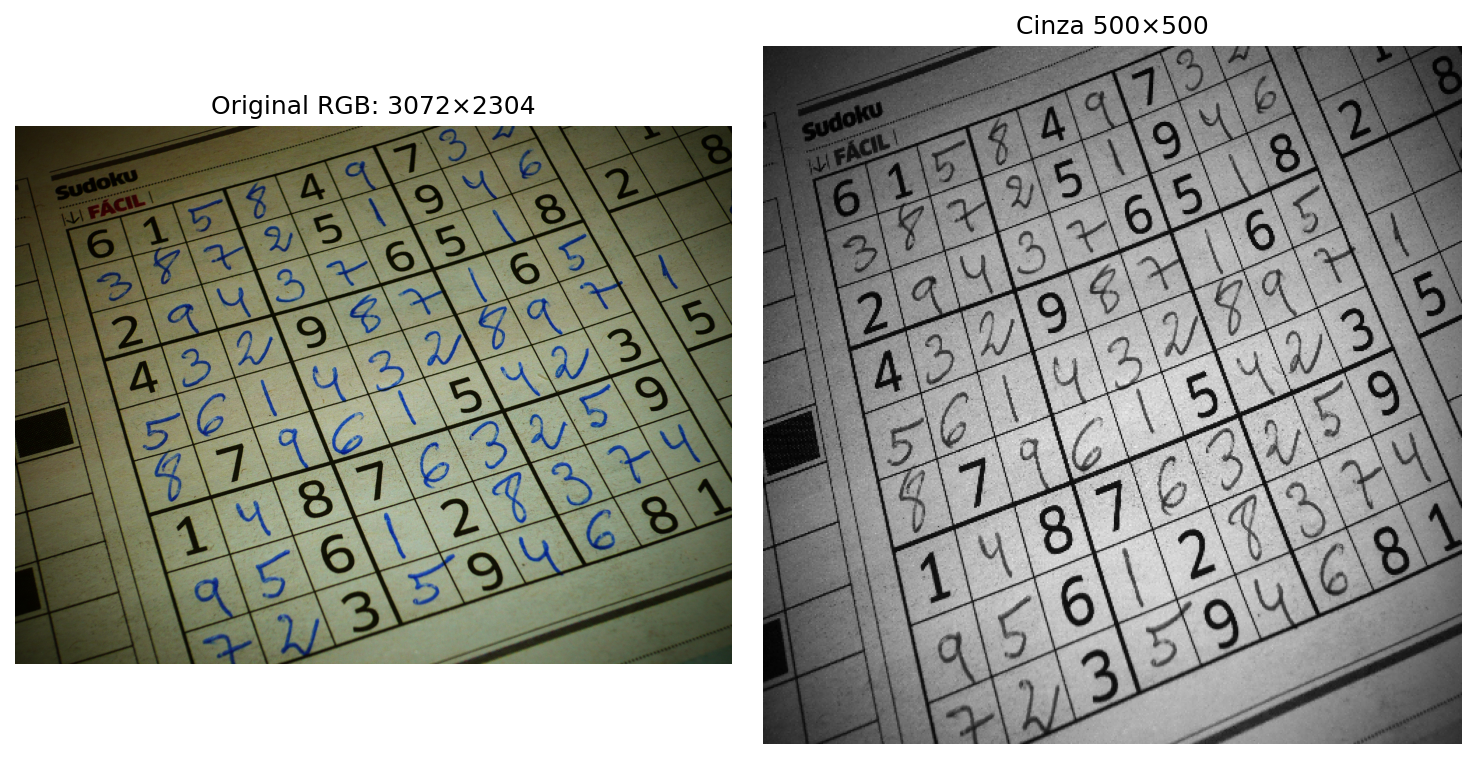

In [ ]:
#| label: fig-02-sudoku-original
#| fig-cap: "Aquisição da imagem de um Sudoku à esquerda. À direita, conversão para tons de cinza e redimensionamento. Crédito: Héctor Rodríguez de Guardamar, Espanha (CC BY 2.0)."
#| echo: false
#| output: true

import numpy as np
import cv2

url = "https://upload.wikimedia.org/wikipedia/commons/e/e7/Sudoku_en_peri%C3%B3dico.jpg"
img_pil = mm.read(url, pil=True)
img_np  = np.array(img_pil)
img_gray  = mm.gray(img_np)
img_small = mm.resize(img_gray, (500, 500))
cv2.imwrite("sudoku.png", img_small)

mm.show(
    [img_np, img_small],
    titles=[
        f"Original RGB: {img_np.shape[1]}×{img_np.shape[0]}",
        "Cinza 500×500"
    ],
    cols=2
)

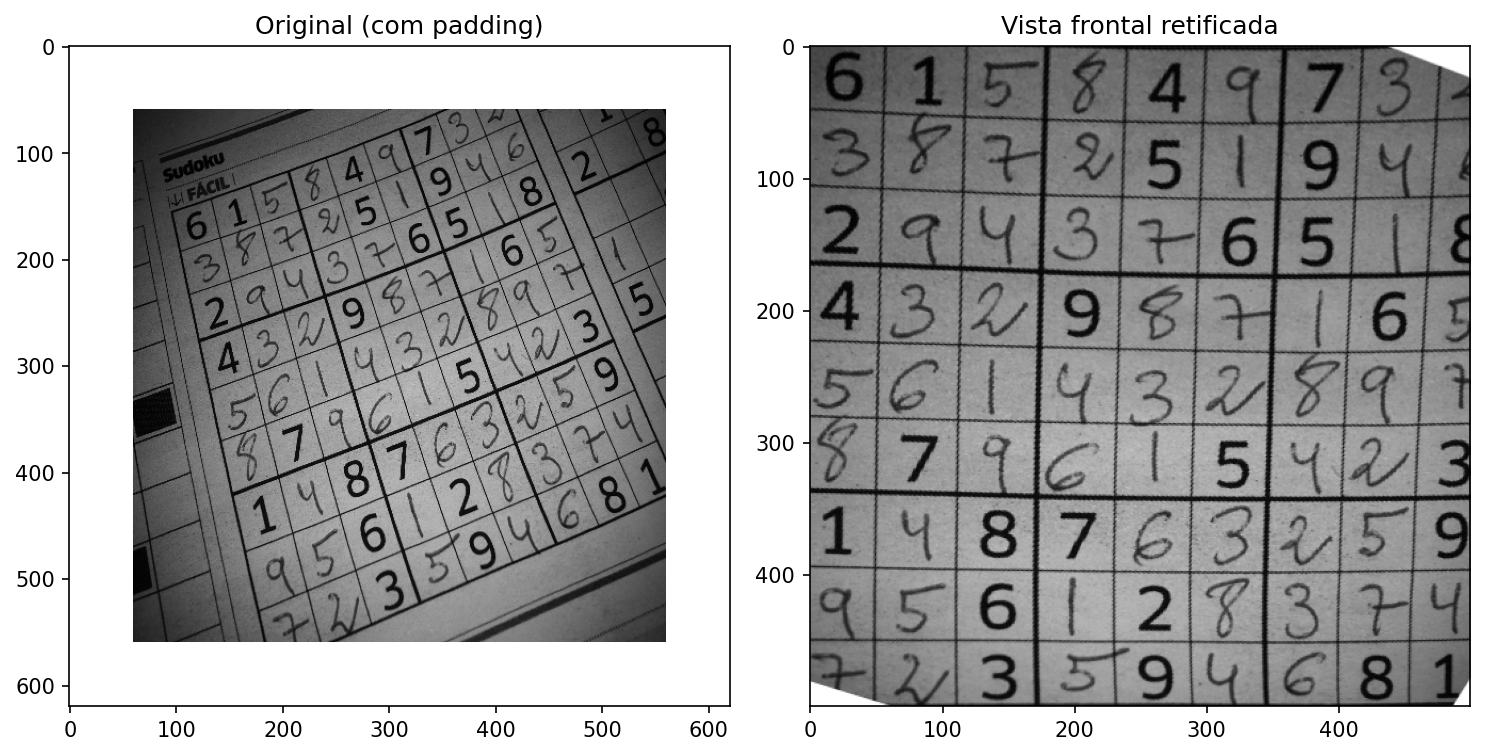

In [ ]:
#| label: fig-02-sudoku2
#| fig-cap: "Correção de perspectiva: original e vista frontal retificada."
#| echo: true
#| output: true

import cv2
import numpy as np

# --- 1. Carrega a imagem salva (sudoku.png) ---
img = mm.read("sudoku.png")                # BGR, 500×500

# --- 2. Padding para não cortar vértices ---
PAD = 60
img_pad = cv2.copyMakeBorder(
    img, PAD, PAD, PAD, PAD,
    cv2.BORDER_CONSTANT, value=[255, 255, 255]
)

# --- 3. Pontos de origem (cantos da grade na imagem expandida) ---
pts1 = np.float32([
    [100, 160],    # TL
    [390, 45],    # TR
    [200, 580],   # BL
    [570, 420],   # BR
])
#     W    H

# --- 4. Pontos de destino (vista frontal 500×500) ---
SIZE = 500
pts2 = np.float32([
    [0,    0],
    [SIZE, 0],
    [0,    SIZE],
    [SIZE, SIZE],
])

# --- 5. Homografia e retificação ---
img_rect = mm.perspective_transform(img_pad, pts1, pts2, size=(SIZE, SIZE))

# --- 6. Exibição ---
mm.show(
    [img_pad, img_rect],
    titles=["Original (com padding)", "Vista frontal retificada"],
    cols=2, figsize=(10, 6), axis=True
)

::: {.content-visible when-format="html"}

In [ ]:
#| label: fig-02-sudoku
#| fig-cap: "Simulador: correção de perspectiva do Sudoku."
#| echo: false
#| output: true


from IPython.display import HTML

HTML("""
<!-- EP: Perspectiva Sudoku -->

<div id="sim-sudoku-persp" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif; max-width: 900px; margin-left: auto; margin-right: auto;">
  <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; display: flex; justify-content: space-between;">
    🎮 Simulador: Perspectiva do Sudoku <span style="background:#e8e0cf; border-radius:40px; padding:2px 10px;">📐 Homografia 3×3 · CC BY 2.0</span>
  </div>
  <div style="padding: 20px; background: white;">
    <div style="display: flex; gap: 20px; justify-content: center; flex-wrap: wrap;">
      <!-- Canvas origem -->
      <div style="text-align: center;">
        <p>📷 Original (expandida) — arraste os cantos laranjas</p>
        <canvas id="canvas-src" width="400" height="400" style="border-radius:12px; border:2px solid #e67e22; background:#e8e2d4; cursor:crosshair;"></canvas>
        <p style="font-size:9px;">Foto: Héctor Rodríguez · CC BY 2.0</p>
      </div>
      <!-- Canvas destino -->
      <div style="text-align: center;">
        <p>✅ Corrigida (400×400) — frontal</p>
        <canvas id="canvas-dst" width="400" height="400" style="border-radius:12px; border:2px solid #2ecc71; background:#f0efe7;"></canvas>
      </div>
    </div>
    <div style="display: flex; gap: 12px; justify-content: center; margin-top: 15px;">
      <button id="btn-reset">↺ Redefinir pontos</button>
      <button id="btn-correct" style="background:#eafaf1; border-color:#2ecc71;">✨ Corrigir Perspectiva</button>
      <button id="btn-pad">🔲 Mostrar padding</button>
    </div>
    <div id="debug-info" style="margin-top: 16px; background:#eef2f5; border-radius:12px; padding:10px; font-family:monospace; font-size:11px; text-align:center;">
      Carregando imagem sudoku.png...
    </div>
  </div>
</div>

<script>
(function(){
  // ----- Elementos -----
  const srcCanvas = document.getElementById('canvas-src');
  const dstCanvas = document.getElementById('canvas-dst');
  const ctxSrc = srcCanvas.getContext('2d');
  const ctxDst = dstCanvas.getContext('2d');
  const btnReset = document.getElementById('btn-reset');
  const btnCorrect = document.getElementById('btn-correct');
  const btnPad = document.getElementById('btn-pad');
  const debugDiv = document.getElementById('debug-info');

  const SIZE = 400;          // canvas quadrado
  const PAD = 32;            // padding em pixels
  let img = null;            // objeto Image
  let imgLoaded = false;
  let points = [];           // 4 pontos [x,y]
  let dragIndex = -1;
  let showPad = false;

  // Pontos iniciais aproximados (cobrem a grade do sudoku)
  function defaultPoints() {
    return [
      [PAD + 48, PAD + 38],   // TL
      [SIZE - PAD - 32, PAD + 28],  // TR
      [PAD + 35, SIZE - PAD - 32],  // BL
      [SIZE - PAD - 28, SIZE - PAD - 24] // BR
    ];
  }

  // ----- Carregar imagem local (sudoku.png) -----
  function loadImage() {
    const imageObj = new Image();
    // Tenta primeiro a imagem local (mais rápida). Se falhar, usa a URL original.
    imageObj.src = "sudoku.png";
    imageObj.crossOrigin = "Anonymous";
    imageObj.onload = () => {
      img = imageObj;
      imgLoaded = true;
      points = defaultPoints();
      drawSource();
      drawPlaceholder();
      debugDiv.innerHTML = "✅ Imagem local carregada! Arraste os pontos laranjas para os cantos da grade.";
    };
    imageObj.onerror = () => {
      // Fallback para a imagem da Wikimedia (mais pesada, mas ainda funcional)
      imageObj.src = "https://upload.wikimedia.org/wikipedia/commons/e/e7/Sudoku_en_peri%C3%B3dico.jpg";
      imageObj.onload = () => {
        img = imageObj;
        imgLoaded = true;
        points = defaultPoints();
        drawSource();
        drawPlaceholder();
        debugDiv.innerHTML = "⚠️ Imagem local não encontrada, usando versão online (pode ser lenta).";
      };
      imageObj.onerror = () => {
        debugDiv.innerHTML = "❌ Erro ao carregar imagem. Verifique o arquivo sudoku.png ou a conexão.";
        imgLoaded = false;
      };
    };
  }

  // Desenha a imagem no canvas de origem com padding e os pontos de controle
  function drawSource() {
    if (!imgLoaded || !img) return;
    ctxSrc.clearRect(0, 0, SIZE, SIZE);
    // Fundo bege
    ctxSrc.fillStyle = "#e9e2d0";
    ctxSrc.fillRect(0, 0, SIZE, SIZE);
    
    // Desenha a imagem dentro da área de padding (centralizada)
    const maxW = SIZE - 2 * PAD;
    const maxH = SIZE - 2 * PAD;
    const scale = Math.min(maxW / img.width, maxH / img.height);
    const drawW = img.width * scale;
    const drawH = img.height * scale;
    const offX = PAD + (maxW - drawW) / 2;
    const offY = PAD + (maxH - drawH) / 2;
    ctxSrc.drawImage(img, offX, offY, drawW, drawH);
    
    // Overlay de padding (opcional)
    if (showPad) {
      ctxSrc.fillStyle = "rgba(52,152,219,0.2)";
      ctxSrc.fillRect(0, 0, SIZE, PAD);
      ctxSrc.fillRect(0, SIZE-PAD, SIZE, PAD);
      ctxSrc.fillRect(0, 0, PAD, SIZE);
      ctxSrc.fillRect(SIZE-PAD, 0, PAD, SIZE);
      ctxSrc.strokeStyle = "#2980b9";
      ctxSrc.setLineDash([4,6]);
      ctxSrc.strokeRect(PAD, PAD, SIZE-2*PAD, SIZE-2*PAD);
      ctxSrc.setLineDash([]);
    }
    
    // Desenhar quadrilátero dos pontos
    if (points.length === 4) {
      ctxSrc.beginPath();
      ctxSrc.moveTo(points[0][0], points[0][1]);
      ctxSrc.lineTo(points[1][0], points[1][1]);
      ctxSrc.lineTo(points[3][0], points[3][1]);
      ctxSrc.lineTo(points[2][0], points[2][1]);
      ctxSrc.closePath();
      ctxSrc.strokeStyle = "#e67e22";
      ctxSrc.lineWidth = 2.5;
      ctxSrc.stroke();
      
      const labels = ["TL","TR","BL","BR"];
      for (let i=0; i<4; i++) {
        ctxSrc.beginPath();
        ctxSrc.arc(points[i][0], points[i][1], 7, 0, 2*Math.PI);
        ctxSrc.fillStyle = "#e67e22";
        ctxSrc.fill();
        ctxSrc.strokeStyle = "white";
        ctxSrc.lineWidth = 2;
        ctxSrc.stroke();
        ctxSrc.fillStyle = "#3a2a1a";
        ctxSrc.font = "bold 11px 'Segoe UI'";
        const dx = (i===0 || i===2) ? -20 : 6;
        const dy = (i<2) ? -10 : 14;
        ctxSrc.fillText(labels[i], points[i][0]+dx, points[i][1]+dy);
      }
    }
  }
  
  function drawPlaceholder() {
    ctxDst.clearRect(0, 0, SIZE, SIZE);
    ctxDst.fillStyle = "#f5f3ea";
    ctxDst.fillRect(0, 0, SIZE, SIZE);
    ctxDst.fillStyle = "#aaa";
    ctxDst.font = "12px sans-serif";
    ctxDst.textAlign = "center";
    ctxDst.fillText("Clique em 'Corrigir Perspectiva'", SIZE/2, SIZE/2-10);
    ctxDst.fillText("para ver o resultado frontal", SIZE/2, SIZE/2+12);
    ctxDst.textAlign = "left";
  }
  
  // ----- Cálculo de Homografia e Warp (versão otimizada) -----
  function getPerspectiveTransform(src, dst) {
    // src e dst: arrays de 4 pontos [x,y]
    const A = [];
    for (let i=0; i<4; i++) {
      const [x,y] = src[i];
      const [xp,yp] = dst[i];
      A.push([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp]);
      A.push([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp]);
    }
    // Resolver A*h = 0 com h[8]=1
    const B = [], C = [];
    for (let i=0; i<8; i++) {
      B.push(A[i].slice(0,8));
      C.push(-A[i][8]);
    }
    const sol = gaussSolve(B, C);
    if (!sol) return null;
    const h = [...sol, 1];
    return [[h[0],h[1],h[2]],[h[3],h[4],h[5]],[h[6],h[7],h[8]]];
  }
  
  function gaussSolve(A, b) {
    const n = A.length;
    const M = A.map((row,i) => [...row, b[i]]);
    for (let i=0; i<n; i++) {
      let maxRow = i;
      for (let k=i+1; k<n; k++) if (Math.abs(M[k][i]) > Math.abs(M[maxRow][i])) maxRow = k;
      [M[i], M[maxRow]] = [M[maxRow], M[i]];
      if (Math.abs(M[i][i]) < 1e-8) return null;
      for (let k=i+1; k<=n; k++) M[i][k] /= M[i][i];
      for (let k=0; k<n; k++) {
        if (k !== i) {
          const factor = M[k][i];
          for (let j=i+1; j<=n; j++) M[k][j] -= factor * M[i][j];
        }
      }
    }
    return M.map(row => row[n]);
  }
  
  function invertMatrix3x3(m) {
    const [[a,b,c],[d,e,f],[g,h,i]] = m;
    const det = a*(e*i - f*h) - b*(d*i - f*g) + c*(d*h - e*g);
    if (Math.abs(det) < 1e-8) return null;
    const invDet = 1/det;
    return [[(e*i-f*h)*invDet, (c*h-b*i)*invDet, (b*f-c*e)*invDet],
            [(f*g-d*i)*invDet, (a*i-c*g)*invDet, (c*d-a*f)*invDet],
            [(d*h-e*g)*invDet, (b*g-a*h)*invDet, (a*e-b*d)*invDet]];
  }
  
  function warpPerspective(srcCanvas, dstCanvas, H, outW, outH) {
    const srcCtx = srcCanvas.getContext('2d');
    const dstCtx = dstCanvas.getContext('2d');
    const srcImg = srcCtx.getImageData(0, 0, srcCanvas.width, srcCanvas.height);
    const dstData = dstCtx.createImageData(outW, outH);
    const srcData = srcImg.data;
    const srcW = srcCanvas.width, srcH = srcCanvas.height;
    const Hinv = invertMatrix3x3(H);
    if (!Hinv) return false;
    
    for (let y=0; y<outH; y++) {
      for (let x=0; x<outW; x++) {
        const denom = Hinv[2][0]*x + Hinv[2][1]*y + Hinv[2][2];
        if (Math.abs(denom) < 1e-6) continue;
        const u = (Hinv[0][0]*x + Hinv[0][1]*y + Hinv[0][2]) / denom;
        const v = (Hinv[1][0]*x + Hinv[1][1]*y + Hinv[1][2]) / denom;
        if (u>=0 && u<srcW-1 && v>=0 && v<srcH-1) {
          const x0 = Math.floor(u), y0 = Math.floor(v);
          const dx = u-x0, dy = v-y0;
          const idx = (y0*srcW + x0)*4;
          const c00 = [srcData[idx], srcData[idx+1], srcData[idx+2]];
          const c10 = [srcData[idx+4], srcData[idx+5], srcData[idx+6]];
          const c01 = [srcData[idx+srcW*4], srcData[idx+srcW*4+1], srcData[idx+srcW*4+2]];
          const c11 = [srcData[idx+srcW*4+4], srcData[idx+srcW*4+5], srcData[idx+srcW*4+6]];
          const r = (1-dx)*(1-dy)*c00[0] + dx*(1-dy)*c10[0] + (1-dx)*dy*c01[0] + dx*dy*c11[0];
          const g = (1-dx)*(1-dy)*c00[1] + dx*(1-dy)*c10[1] + (1-dx)*dy*c01[1] + dx*dy*c11[1];
          const b = (1-dx)*(1-dy)*c00[2] + dx*(1-dy)*c10[2] + (1-dx)*dy*c01[2] + dx*dy*c11[2];
          const idxDst = (y*outW + x)*4;
          dstData.data[idxDst]=r; dstData.data[idxDst+1]=g; dstData.data[idxDst+2]=b; dstData.data[idxDst+3]=255;
        } else {
          const idxDst = (y*outW + x)*4;
          dstData.data[idxDst]=240; dstData.data[idxDst+1]=235; dstData.data[idxDst+2]=220; dstData.data[idxDst+3]=255;
        }
      }
    }
    dstCtx.putImageData(dstData, 0, 0);
    return true;
  }
  
  function correctPerspective() {
    if (!imgLoaded) { debugDiv.innerHTML = "Aguardando imagem carregar."; return; }
    // pts1: pontos atuais (origem)
    const pts1 = points.map(p => [p[0], p[1]]);
    const pts2 = [[0,0],[SIZE,0],[0,SIZE],[SIZE,SIZE]];
    const H = getPerspectiveTransform(pts1, pts2);
    if (!H) { debugDiv.innerHTML = "Erro: pontos inválidos (colineares)."; return; }
    // Criar canvas temporário com o conteúdo atual do srcCanvas (inclui imagem e pontos)
    const tempCanvas = document.createElement('canvas');
    tempCanvas.width = SIZE;
    tempCanvas.height = SIZE;
    tempCanvas.getContext('2d').drawImage(srcCanvas, 0, 0);
    const success = warpPerspective(tempCanvas, dstCanvas, H, SIZE, SIZE);
    if (success) {
      debugDiv.innerHTML = `✅ Homografia aplicada. pts1: TL(${Math.round(pts1[0][0])},${Math.round(pts1[0][1])}) TR(${Math.round(pts1[1][0])},${Math.round(pts1[1][1])}) BL(${Math.round(pts1[2][0])},${Math.round(pts1[2][1])}) BR(${Math.round(pts1[3][0])},${Math.round(pts1[3][1])}) → retângulo ${SIZE}×${SIZE}.`;
    } else {
      debugDiv.innerHTML = "❌ Falha na warp (homografia singular). Ajuste os pontos.";
    }
  }
  
  // ----- Interação de arrasto -----
  function getMousePos(e, canvas) {
    const rect = canvas.getBoundingClientRect();
    const scaleX = canvas.width / rect.width;
    const scaleY = canvas.height / rect.height;
    let clientX, clientY;
    if (e.touches) { clientX = e.touches[0].clientX; clientY = e.touches[0].clientY; e.preventDefault(); }
    else { clientX = e.clientX; clientY = e.clientY; }
    return [(clientX - rect.left)*scaleX, (clientY - rect.top)*scaleY];
  }
  
  srcCanvas.addEventListener('mousedown', (e) => {
    const [mx,my] = getMousePos(e, srcCanvas);
    for (let i=0; i<points.length; i++) {
      if (Math.hypot(mx-points[i][0], my-points[i][1]) < 12) {
        dragIndex = i;
        srcCanvas.style.cursor = 'grabbing';
        break;
      }
    }
  });
  window.addEventListener('mousemove', (e) => {
    if (dragIndex === -1) return;
    const [mx,my] = getMousePos(e, srcCanvas);
    points[dragIndex] = [Math.min(SIZE-5, Math.max(5,mx)), Math.min(SIZE-5, Math.max(5,my))];
    drawSource();
    debugDiv.innerHTML = `Movendo ponto ${dragIndex} → (${Math.round(points[dragIndex][0])}, ${Math.round(points[dragIndex][1])})`;
  });
  window.addEventListener('mouseup', () => { dragIndex = -1; srcCanvas.style.cursor = 'crosshair'; });
  srcCanvas.addEventListener('touchstart', (e) => { e.preventDefault(); const [mx,my]=getMousePos(e,srcCanvas); for(let i=0;i<points.length;i++) if(Math.hypot(mx-points[i][0], my-points[i][1])<15) dragIndex=i; });
  window.addEventListener('touchmove', (e) => { if(dragIndex!==-1){ e.preventDefault(); const [mx,my]=getMousePos(e,srcCanvas); points[dragIndex]=[Math.min(SIZE-5,Math.max(5,mx)), Math.min(SIZE-5,Math.max(5,my))]; drawSource(); } });
  window.addEventListener('touchend', () => { dragIndex = -1; });
  
  btnReset.addEventListener('click', () => { points = defaultPoints(); showPad=false; drawSource(); drawPlaceholder(); debugDiv.innerHTML = "Pontos redefinidos."; });
  btnCorrect.addEventListener('click', correctPerspective);
  btnPad.addEventListener('click', () => { showPad = !showPad; drawSource(); });
  
  loadImage();
})();
</script>
""")

:::

::: {.content-visible when-format="pdf"}
![ Simulador: correção de perspectiva do Sudoku. ](imagens/fig-02-sudoku.png){#fig-02-sudoku}
:::

In [ ]:
%%writefile EP02_11.py
# Código Python

Overwriting EP02_11.py


In [ ]:
TestSuite("EP02_11.py").run()